Environment name: `r_env_corr`

# 0. - Imports and paths

In [1]:
setwd(dir = "/disk2/user/gabgam/the_project/5_integration_and_correlation/")

In [2]:
suppressMessages(suppressWarnings(source("./utils/source_satac.R")))
library(biovizBase)
library(extrafont) # install.packages("extrafont")
library(Matrix)
library(ape)
library(clustree)

Registering fonts with R

Registered S3 method overwritten by 'ape':
  method   from 
  plot.mst spdep


Attaching package: 'ape'


The following object is masked from 'package:dplyr':

    where


The following object is masked from 'package:ggpubr':

    rotate


The following object is masked from 'package:Biostrings':

    complement


Loading required package: ggraph


Attaching package: 'ggraph'


The following object is masked from 'package:sp':

    geometry




Loading the fonts.

In [3]:
# Fetch DM Sans font file from https://github.com/google/fonts/blob/main/ofl/dmsans/DMSans%5Bopsz%2Cwght%5D.ttf 
# or, better, https://fonts.google.com/specimen/DM+Sans
# Import only DMSans-Medium
# font_import(paths = "../fonts/static/", prompt = FALSE, recursive = FALSE, pattern = "DMSans-Medium.ttf") # select just the Medium one
# loadfonts()  # Load registered fonts

# # verify if the font is available:
# fonts()

In [4]:
# # for font in Base R plots
# par(family = "DM Sans Medium")
# plot(1: 2, main = "Title in Custom Font")

sATAC sample paths and names.

In [5]:
PATH_TO_sATAC_DATA_FOLDER <- "../data/spatial_atac/"

SELECTED_sATAC_SAMPLE <- "220327_C1"
SATAC_SAMPLE_NAME <- "satac_C1_v3_allspots"

# peaks obtained from https://www.science.org/doi/10.1126/science.aav1898
BRCA_PEAK_CALLS <- paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/BRCA_peakCalls.csv")

Derived path for saving output and figures.

In [6]:
PATH_TO_FIGURES_SATAC <- paste0("figures/sATAC_preprocessing/", SATAC_SAMPLE_NAME, "/")
# PATH_TO_FIGURES_COMPARISON <- paste0("figures/integration_comparison/", SATAC_SAMPLE_NAME, "_&_", VISIUM_SAMPLE_NAME, "/")

PATH_TO_sATAC_PREPROCESSING_OUTPUT <- paste0("output/sATAC_preprocessing/", SATAC_SAMPLE_NAME, "/")

PATH_TO_sATAC_PREPROCESSING_OUTPUT_RDS <- paste0(PATH_TO_sATAC_PREPROCESSING_OUTPUT, "RDS_files/")

In [7]:
paths_to_create <- c(PATH_TO_FIGURES_SATAC,
                    #  PATH_TO_FIGURES_COMPARISON,
                     PATH_TO_sATAC_PREPROCESSING_OUTPUT,
                     PATH_TO_sATAC_PREPROCESSING_OUTPUT_RDS)

for (path in paths_to_create) {
  dir.create(path, recursive = TRUE, showWarnings = FALSE)
}

In [8]:
image_cluster_paths <- list(
  satac_100um_kmeans_original_wsi = "../4_features_clustering/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv",
  satac_100um_leiden_original_wsi = "../4_features_clustering/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_100um_ORIGINAL WSI.csv",
  satac_100um_kmeans_from_wsi_macenko = "../4_features_clustering/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_100um_fromWSI_histomicsTK_macenko_nomasking.csv",
  satac_100um_leiden_from_wsi_macenko = "../4_features_clustering/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_100um_fromWSI_histomicsTK_macenko_nomasking.csv",
  
  satac_68um_kmeans_original_wsi = "../4_features_clustering/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.csv",
  satac_68um_leiden_original_wsi = "../4_features_clustering/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_68um_ORIGINAL WSI.csv",
  satac_68um_kmeans_from_wsi_macenko = "../4_features_clustering/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_kmeans_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_68um_fromWSI_histomicsTK_macenko_nomasking.csv",
  satac_68um_leiden_from_wsi_macenko = "../4_features_clustering/output/UNI2-h/satac_C1_v3_allspots_&_visium_FFPE_dcis_idc_10X_img_not_changed_allspots/on_individual_samples/6_clusters/tissue_position_list_with_6_leiden_clusters_satac_C1_&_v3_allspots_&_target_is_reference_full_68um_fromWSI_histomicsTK_macenko_nomasking.csv"
)

image_cluster_data <- lapply(image_cluster_paths, read.csv, row.names = 1)

# assign to individual variables in the global environment
list2env(image_cluster_data)

<environment: 0x563f55abad00>

---
# 1. - Creating the initial sATAC object

## 1.1 - Creating table with paths to all files

In [9]:
# set paths to raw data and metadata
dirs <- list.dirs(paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/"), recursive = F, full.names = F)
table <- list()


# create a table containing paths to raw and meta data (i.e., output from cellranger + spatial info)
for(i in dirs){
  table[[i]] <- list(samples = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/raw_peak_bc_matrix.h5"),
                  singlecell = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/singlecell.csv"),
                  fragments = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/fragments.tsv.gz"),
                  tissue_paths = paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/", i, "_tissue.tsv"),
                  spotfiles = paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/", i, "_tissue.csv"))
}

infoTable <- do.call("rbind", table) %>% as.data.frame()
#infoTable <- as.data.frame(table, stringsAsFactors = FALSE)


## 1.2 - Creating count Object for peaks

From the Signac [tutorial](https://stuartlab.org/signac/articles/pbmc_vignette):
```r
fragpath <- '10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv.gz'

# Define cells
# If you already have a list of cell barcodes to use you can skip this step
total_counts <- CountFragments(fragpath)
cutoff <- 1000 # Change this number depending on your dataset!
barcodes <- total_counts[total_counts$frequency_count > cutoff, ]$CB

# Create a fragment object
frags <- CreateFragmentObject(path = fragpath, cells = barcodes)

# First call peaks on the dataset
# If you already have a set of peaks you can skip this step
peaks <- CallPeaks(frags)

# Quantify fragments in each peak
counts <- FeatureMatrix(fragments = frags, features = peaks, cells = barcodes)
```


In [10]:
object <- list(md = list(),
               frag = list(),
               counts = list())

# build new matrices with new peak set
# peaks obtained from https://www.science.org/doi/10.1126/science.aav1898
# load peaks and create genomicranges object
gr <- read.csv(
  file = BRCA_PEAK_CALLS,
  col.names = c("chr", "start", "end"),
  sep = ";"
) %>% makeGRangesFromDataFrame()

# create fragment objects and count matrices for each section separately
for(i in seq_along(dirs)){
  # folder = paste0(PATH_TO_sATAC_DATA_FOLDER, "combined/")
  folder = strsplit(infoTable$samples[[i]], "raw_peak_bc_matrix.h5") %>% unlist()
  # load metadata
  object$md[[i]] <- read.table(
    file = infoTable$singlecell[[i]],
    stringsAsFactors = FALSE,
    sep = ",",
    header = TRUE,
    row.names = 1
  )[-1, ] # remove the first row (NO_BARCODE)
  
  # create fragment objects
  object$frag[[i]] <- CreateFragmentObject(
    path = infoTable$fragments[[i]],
    cells = rownames(object$md[[i]])
  )
  
  if (file.exists(paste0(folder, "brca_peak_bc_matrix.h5"))) {
    message("File exists.")
    object$counts[[i]] <- Read10X_h5(paste0(folder, "brca_peak_bc_matrix.h5"))
    
  } else {
    
    # make count matrix
    object$counts[[i]] <- FeatureMatrix(
      fragments = object$frag[[i]],
      features = gr,
      cells = rownames(object$md[[i]])
    )
    
    write10xCounts(path = paste0(folder, "brca_peak_bc_matrix.h5"),
                   x = object$counts[[i]],
                   type = "HDF5") # save new count matrix
  }
  
}

Computing hash

File exists.

Computing hash

File exists.

Computing hash

File exists.



## 1.3 - Building the correct tissue list file

In [11]:
# make tissue position files
for(i in seq_along(infoTable$tissue_paths)){
  spotfile <- read.table(infoTable$tissue_paths[[i]], sep = "\t", header = T)
  
  spotfile_tissue <- cbind(
    spotfile$row, #array_row
    spotfile$col, #array_col
    spotfile$x, #pxl_row_in_fullres
    spotfile$y #pxl_col_in_fullres
  ) %>% as.data.frame()
  tissue <- rep(1, nrow(spotfile_tissue))
  spotfile_tissue <- cbind(tissue, spotfile_tissue)
  rownames(spotfile_tissue) <- paste0(spotfile$barcode, "-1")
  
  # save new tissue position file with the correct columns for creating STutility object as .csv files
  write.csv(spotfile_tissue, 
            paste0(strsplit(infoTable$tissue_paths[[i]], "tsv"), "csv"), 
            sep = ",")
  
}

Warning message in write.csv(spotfile_tissue, paste0(strsplit(infoTable$tissue_paths[[i]], :
"attempt to set 'sep' ignored"
Warning message in write.csv(spotfile_tissue, paste0(strsplit(infoTable$tissue_paths[[i]], :
"attempt to set 'sep' ignored"
Warning message in write.csv(spotfile_tissue, paste0(strsplit(infoTable$tissue_paths[[i]], :
"attempt to set 'sep' ignored"


Loading the files just created for each of the sections.

In [12]:
# load spotfiles
tissue_md <- list()
object$mtx <- list()

for(i in seq_along(infoTable$spotfiles)){
  spotfile <- read.csv(infoTable$spotfiles[[i]],
                       col.names = c("barcode", "tissue", "y", "x", "pixel_y", "pixel_x")
  )
  
  # filter count matrix to retain only spots overlaying tissue
  mtx <- object$counts[[i]] # barcodes extracted from here
  mtx <- mtx[,colnames(mtx) %in% spotfile$barcode] 
  
  object$mtx[[i]] <- mtx
  
  #save spot info in a list
  tissue_md[[i]] <- spotfile
}

---
# 2. - Chromatin Assay object and LSI computing
why do they perform normalisation here???

In the Signac [tutorial](https://stuartlab.org/signac/articles/pbmc_vignette) they do:
```r
chrom_assay <- CreateChromatinAssay(
  counts = counts,
  sep = c(":", "-"),
  fragments = "10k_pbmc_ATACv2_nextgem_Chromium_Controller_fragments.tsv.gz",
  min.cells = 10,
  min.features = 200
)
```

In [13]:
signac_object <- list()

# create signac objects for each section and run normalization and dimensionality reduction
for(i in seq_along(infoTable$spotfiles)){
  
  # creating the Chromatin Assay
  assay <- CreateChromatinAssay(object$mtx[[i]], 
                                fragments = object$frag[[i]])
  
  # creating the signac object and performing an initial filtering 
  signac_object[[i]] <- CreateSeuratObject(assay, 
                                           assay = "peaks", 
                                           meta.data=object$md[[i]],
                                           min.cells = 10,
                                           min.features = 200)

  signac_object[[i]]$section <- rownames(infoTable)[i]
  signac_object[[i]]$sample <- i
  
  # compute LSI
  # signac_object[[i]] <- FindTopFeatures(signac_object[[i]], min.cutoff = 10)
  # signac_object[[i]] <- RunTFIDF(signac_object[[i]])
  # signac_object[[i]] <- RunSVD(signac_object[[i]])
}

# naming the objects in the correct way
names(signac_object) <- rownames(infoTable)
signac_object

Warning message in CreateChromatinAssay(object$mtx[[i]], fragments = object$frag[[i]]):
"Overlapping ranges supplied. Ranges should be non-overlapping."
Warning message in CreateChromatinAssay(object$mtx[[i]], fragments = object$frag[[i]]):
"Overlapping ranges supplied. Ranges should be non-overlapping."
Warning message in CreateChromatinAssay(object$mtx[[i]], fragments = object$frag[[i]]):
"Overlapping ranges supplied. Ranges should be non-overlapping."


$`220327_C1`
An object of class Seurat 
215978 features across 3538 samples within 1 assay 
Active assay: peaks (215978 features, 0 variable features)
 2 layers present: counts, data

$`220327_C2`
An object of class Seurat 
215978 features across 2795 samples within 1 assay 
Active assay: peaks (215978 features, 0 variable features)
 2 layers present: counts, data

$`220327_D2`
An object of class Seurat 
215978 features across 3533 samples within 1 assay 
Active assay: peaks (215978 features, 0 variable features)
 2 layers present: counts, data


Not normalised with LSI in this case.

The normalisation happens on the `data` object.

## 2.1 - Adding the spatial data to meta

In [14]:
# add spatial data to meta
for(i in seq_along(infoTable$tissue_paths)){
  # tissue_md[[i]]$barcode <- paste0(tissue_md[[i]]$barcode, "_", i)
  tissue_md[[i]]$barcode <- paste0(tissue_md[[i]]$barcode, "_", i)
  rownames(tissue_md[[i]]) <- tissue_md[[i]]$barcode
  signac_object[[i]] <- AddMetaData(signac_object[[i]], tissue_md[[i]])
}

In [15]:
names(signac_object)

[1] "220327_C1" "220327_C2" "220327_D2"

## 2.2 - Adding the images

In [16]:
# Create a list to store Seurat objects, each with its own spatial image
seurat_list <- list()

# Create a metadata table (infoTable) containing file paths for each sample
table <- list()
for(i in names(signac_object)){
  table[[i]] <- c(samples = paste0(PATH_TO_sATAC_DATA_FOLDER, "outs/", i, "/brca_peak_bc_matrix.h5"),
                  spotfiles = paste0(PATH_TO_sATAC_DATA_FOLDER, "github_folder/meta/", i, "_tissue.csv"),
                  imgs = paste0(PATH_TO_sATAC_DATA_FOLDER, "spatial/", i, "_cropped.jpg"))
}

infoTable <- do.call("rbind", table) %>% as.data.frame()

# Iterate over all samples to process them separately
for (i in seq_along(dirs)) {
  sample_name <- dirs[i]
  
  # Read spatial barcode positions
  xy.raw <- setNames(read.csv(file = infoTable$spotfiles[i]), 
                     nm = c("barcode", "tissue", "y", "x", "pixel_y", "pixel_x"))
  xy <- xy.raw[, c("x", "y")]
  
  # Load and scale the corresponding image
  img_path <- infoTable$imgs[i]
  img <- readJPEG(img_path)
  
  sf <- c(ncol(img)/128, nrow(img)/78)
  xy$x <- xy$x * sf[1]
  xy$y <- xy$y * sf[2]
  
  # Create a spot selection table with updated pixel coordinates
  spotfile <- data.frame(xy.raw$barcode, xy.raw$tissue, xy.raw$y, xy.raw$x, round(xy$y), round(xy$x))
  spotfile_path <- paste0(strsplit(infoTable$spotfiles[i], ".csv"), "_positions_list.csv")
  write.table(spotfile, file = spotfile_path, sep = ",", quote = F, row.names = F, col.names = F)
  
  # Update infoTable to reference the new spotfile
  infoTable$spotfiles[i] <- spotfile_path
  
  # Create a Seurat object for each sample
  se <- InputFromTable(infoTable[i, , drop = FALSE], scaleVisium = 1)
  se <- LoadImages(se, time.resolve = FALSE)
  
  # Store the Seurat object with the sample name
  # seurat_list[[sample_name]] <- se
  signac_object[[i]]@tools[["Staffli"]] <- se@tools$Staffli # create STutility object for spatial plots
}


Using spotfiles to remove spots outside of tissue


Warning message:
"Only 1 scaleVisium provided. Using this scalefactor for all samples ... 
"


Loading ../data/spatial_atac/outs/220327_C1/brca_peak_bc_matrix.h5 count matrix from a 'Visium' experiment


Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 8.0 GiB"
Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 5.7 GiB"



------------- Filtering (not including images based filtering) -------------- 
  Spots removed:  0  
  Genes removed:  3781  
After filtering the dimensions of the experiment is: [212197 genes, 3538 spots] 
Loading images for 1 samples: 
  Reading ../data/spatial_atac/spatial/220327_C1_cropped.jpg for sample 1 ... 
  Scaling down sample 1 image from 10914x11438 pixels to 400x419 pixels 


...


------------- Filtering (not including images based filtering) -------------- 
  Spots removed:  0  
  Genes removed:  3390  
After filtering the dimensions of the experiment is: [212588 genes, 2795 spots] 
Loading images for 1 samples: 
  Reading ../data/spatial_atac/spatial/220327_C2_cropped.jpg for sample 1 ... 
  Scaling down sample 1 image from 10913x11438 pixels to 400x419 pixels 
Using spotfiles to remove spots outside of tissue


Warning message:
"Only 1 scaleVisium provided. Using this scalefactor for all samples ... 
"


Loading ../data/spatial_atac/outs/220327_D2/brca_peak_bc_matrix.h5 count matrix from a 'Visium' experiment


Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 8.0 GiB"
Warning message in asMethod(object):
"sparse->dense coercion: allocating vector of size 5.7 GiB"



------------- Filtering (not including images based filtering) -------------- 
  Spots removed:  0  
  Genes removed:  2578  
After filtering the dimensions of the experiment is: [213400 genes, 3533 spots] 
Loading images for 1 samples: 
  Reading ../data/spatial_atac/spatial/220327_D2_cropped.jpg for sample 1 ... 
  Scaling down sample 1 image from 10914x11438 pixels to 400x419 pixels 


---

## 2.3 - Selecting just my sample and spots in the overlapped image

In [17]:
# Extract Only `220327_C1`
signac_selected <- signac_object[[SELECTED_sATAC_SAMPLE]]

# Save Processed Object
# saveRDS(signac_selected, paste0(PATH_TO_sATAC_PREPROCESSING_OUTPUT, paste0("2", SELECTED_sATAC_SAMPLE, "_signac_object.rds")))
# saveRDS(signac_selected, paste0(PATH_TO_sATAC_PREPROCESSING_OUTPUT, paste0("2_", SELECTED_sATAC_SAMPLE, "_selected_signac_object.rds")))

# Print Summary
signac_selected

An object of class Seurat 
215978 features across 3538 samples within 1 assay 
Active assay: peaks (215978 features, 0 variable features)
 2 layers present: counts, data

In [18]:
signac_selected@tools[["Staffli"]]

An object of class Staffli 
3538 spots across 1 samples. 

Available image representations: 
   raw 

In [19]:
DefaultAssay(signac_selected) <- "peaks"
dim(signac_selected)

[1] 215978   3538

Using one of the image-based clustering files to extract the spots that really overlapped the analysied slice.

In [20]:
spots_in_image <- image_cluster_data$satac_100um_kmeans_original_wsi

Performing the real spots intersection.

In [21]:
cluster_df_filtered <- spots_in_image %>%
  filter(!is.na(Cluster)) %>%
  mutate(barcode = as.character(barcode),
         cluster_label = as.factor(Cluster)) # uses Cluster from the image clustering

# Only keep matching barcodes
cluster_df_filtered$barcode <- paste0(cluster_df_filtered$barcode, "-1") # adapting to the sATAC barcode names system
barcodes_to_keep <- intersect(cluster_df_filtered$barcode, colnames(signac_selected))
signac_selected <- subset(signac_selected, cells = barcodes_to_keep)

Notice the change of dimension compared to before.

In [22]:
dim(signac_selected)

[1] 215978   3332

---
# 3. - Quality Control

As a part of the preprocesing, first of all, we remove the features that correspond to chromosome scaffolds e.g. (KI270713.1) or other sequences instead of the (22+2) standard chromosomes.

## 3.1 - Keeping only normal chromosomes

In [23]:
peaks.keep <- seqnames(granges(signac_selected)) %in% standardChromosomes(granges(signac_selected))
signac_selected <- signac_selected[as.vector(peaks.keep), ]

## 3.2 - Attaching the correct annotation

We can also add gene annotations to the object for the human genome. This will allow downstream functions to pull the gene annotation information directly from the object.

Multiple patches are released for each genome assembly. When dealing with mapped data, it is advisable to use the annotations from the same assembly patch that was used to perform the mapping.

Usually, you can recover the used reference from the dataset summary; in this case, we will retrieve the information from the spatial ATAC article or from the code itself (where they just say "hg38").\
Thanks to this, we can see that the reference used to perform the mapping was “GRCh38-2020-A”, which corresponds to the Ensembl v98 patch release.

In [24]:
annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86) #GRCh38.p7, Oct 2016 -> v86
seqlevels(annotations) <- paste0('chr', seqlevels(annotations)) # just like UCSC genome annotations
genome(annotations) <- "hg38"
suppressWarnings(Annotation(signac_selected) <- annotations)

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

## 3.3 - Computing QC Metrics
We can now compute some QC metrics for the scATAC-seq experiment. We currently suggest the following metrics below to assess data quality. As with scRNA-seq, the expected range of values for these parameters will vary depending on your biological system, cell viability, and other factors.

Remember: Signac extracts the fragment counts per peak for each spot. Then:
1.  `CreateChromatinAssay()` stores the peak x spot count matrix.
2.  `CreateSeuratObject()` automatically computes:

    - `nCount_peaks` = Total number of fragments per spot.
    - `nFeature_peaks` = The number of distinct peaks (open chromatin regions) that contain at least one read in a given spot.

So, we are going to check:
-   Nucleosome banding pattern: The histogram of DNA fragment sizes (determined from the paired-end sequencing reads) should exhibit a strong nucleosome banding pattern corresponding to the length of DNA wrapped around a single nucleosome. We calculate this per single cell, and quantify the approximate ratio of mononucleosomal to nucleosome-free fragments (stored as nucleosome_signal)

-   Transcriptional start site (TSS) enrichment score: The ENCODE project has defined an ATAC-seq targeting score based on the ratio of fragments centered at the TSS to fragments in TSS-flanking regions (see https://www.encodeproject.org/data-standards/terms/). Poor ATAC-seq experiments typically will have a low TSS enrichment score. We can compute this metric for each cell with the `TSSEnrichment()` function, and the results are stored in metadata under the column name TSS.enrichment.

-   Total number of fragments in peaks: A measure of cellular sequencing depth / complexity. Cells with very few reads may need to be excluded due to low sequencing depth. Cells with extremely high levels may represent doublets, nuclei clumps, or other artefacts.

-   Fraction of fragments in peaks: Represents the fraction of all fragments that fall within ATAC-seq peaks. Cells with low values (i.e. <15-20%) often represent low-quality cells or technical artifacts that should be removed. Note that this value can be sensitive to the set of peaks used.

-   Ratio reads in genomic blacklist regions: The ENCODE project has provided a list of [blacklist regions](https://github.com/Boyle-Lab/Blacklist), representing reads which are often associated with artefactual signal. Cells with a high proportion of reads mapping to these areas (compared to reads mapping to peaks) often represent technical artifacts and should be removed. ENCODE blacklist regions for human (hg19 and hg38), mouse (mm9 and mm10), Drosophila (dm3 and dm6), and C. elegans (ce10 and ce11) are included in the Signac package. The `FractionCountsInRegion()` function can be used to calculate the fraction of all counts within a given set of regions per cell. We can use this function and the blacklist regions to find the fraction of blacklist counts per cell.

Note that the last three metrics can be obtained from the output of CellRanger (which is stored in the object metadata).

In [25]:
# print(names(signac_selected@meta.data))

In [26]:
DefaultAssay(signac_selected) <- "peaks"

In [27]:
# compute nucleosome signal score per cell
signac_selected <- NucleosomeSignal(object = signac_selected)

# compute TSS enrichment score per cell
signac_selected <- TSSEnrichment(object = signac_selected, fast = FALSE)

# add fraction of reads in peaks
signac_selected$fract_reads_in_peaks <- signac_selected$peak_region_fragments / signac_selected$passed_filters * 100

# Fraction of Reads in Peaks (FRiP Score)
signac_selected$FRiP <- signac_selected$nFeature_peaks / signac_selected$nCount_peaks
# Mitochondrial Read Percentage
signac_selected$mitoRatio <- signac_selected$mitochondrial / signac_selected$total

# add blacklist ratio
signac_selected$blacklist_ratio <- FractionCountsInRegion(
  object = signac_selected, 
  assay = 'peaks',
  regions = blacklist_hg38_unified
)

Extracting TSS positions

Finding + strand cut sites

Finding - strand cut sites

Computing mean insertion frequency in flanking regions

Normalizing TSS score



The relationship between variables stored in the object metadata can be visualized using the `DensityScatter()` function. This can also be used to quickly find suitable cutoff values for different QC metrics by setting `quantiles=TRUE`:

### 3.3.1 - Density plot

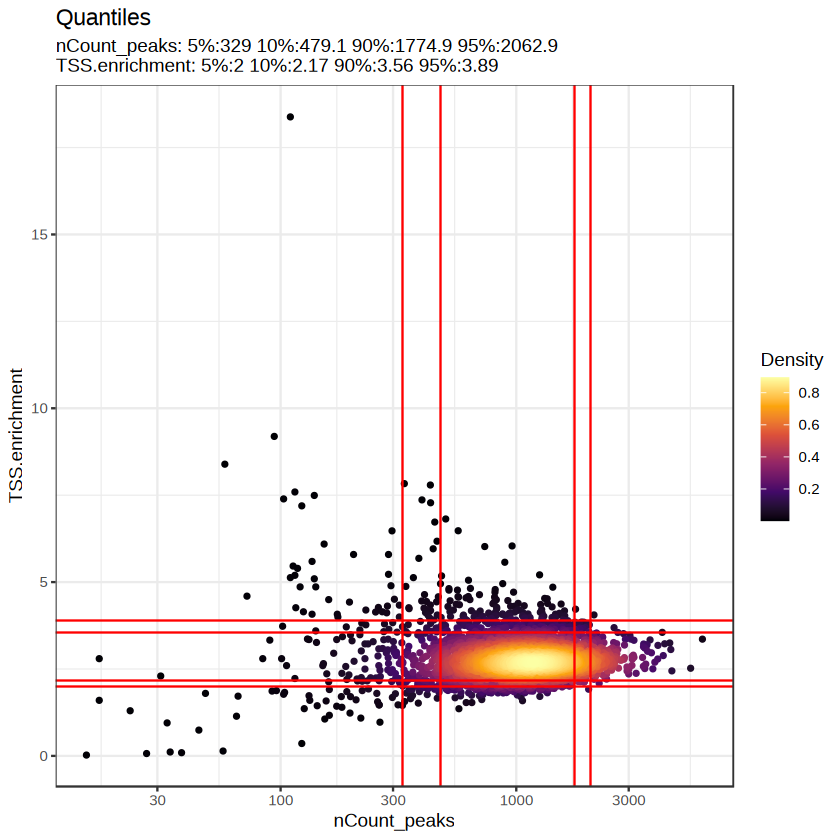

In [28]:
DensityScatter(signac_selected, x = 'nCount_peaks', y = 'TSS.enrichment', log_x = TRUE, quantiles = TRUE)

### 3.3.2 - TSS Enrichment
**TSS Enrichment Score**

-   Measures accessibility at transcription start sites (TSS).
-   Similar to bulk/single-cell ATAC, high scores indicate open chromatin around TSS.
-   Good threshold: TSS enrichment > 8-10 in snATAC-seq, but might be lower in spatial ATAC.

`geom_smooth()` using formula = 'y ~ x'


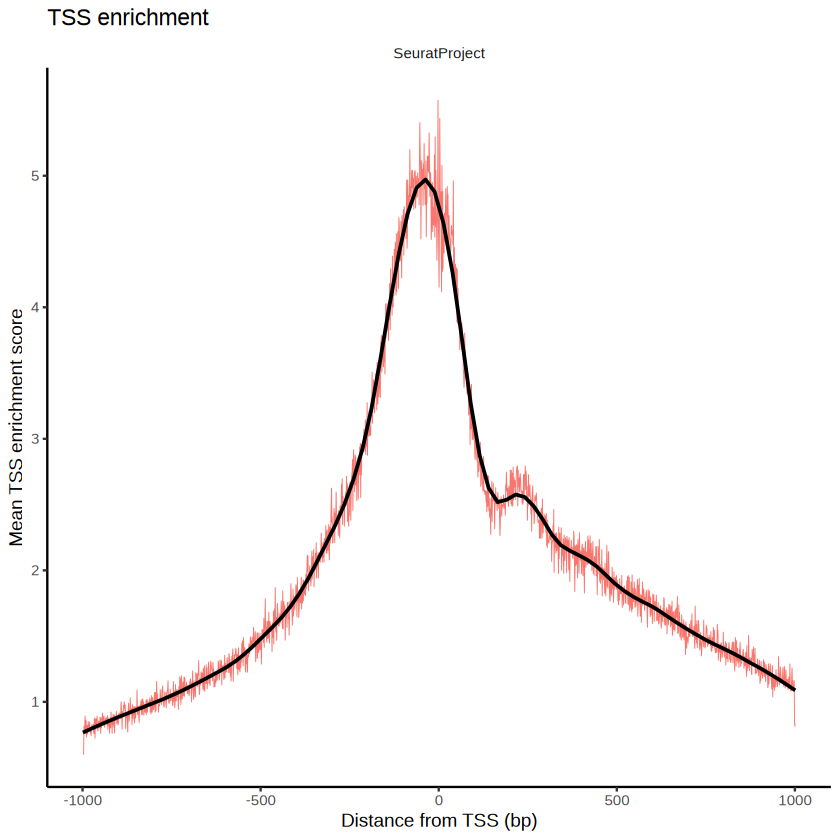

In [29]:
p2 <- TSSPlot(signac_selected)
p2 + geom_smooth(method = "loess", span = 0.15, se = FALSE, color = "black", linewidth = 0.8)

We can also look at the fragment length periodicity for all the cells, and group by cells with high or low nucleosomal signal strength. You can see that cells that are outliers for the mononucleosomal / nucleosome-free ratio (based on the plots above) have different nucleosomal banding patterns. The remaining cells exhibit a pattern that is typical for a successful ATAC-seq experiment.

### 3.3.3 - Fragments length

Warning message:
"Removed 44 rows containing non-finite outside the scale range (`stat_bin()`)."
Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


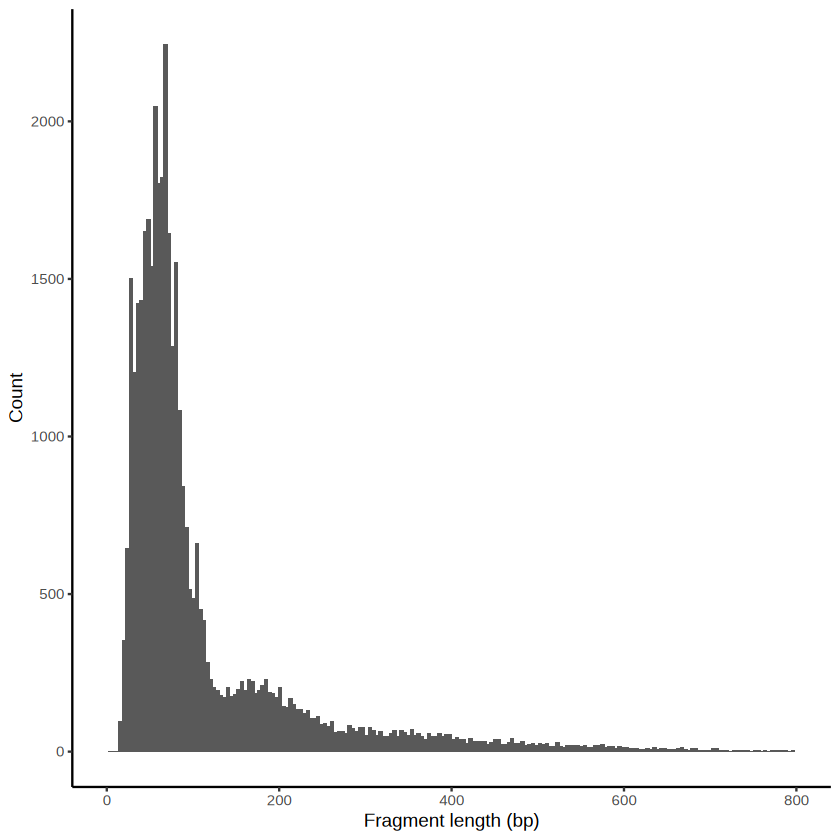

In [30]:
FragmentHistogram(object = signac_selected)

### 3.3.4 - FRiP score
Fraction of Reads in Peaks (FRiP Score)
-   Measures signal-to-noise ratio by computing the fraction of fragments that fall within called peaks.
-   High FRiP (>0.2-0.3) indicates good quality; low FRiP (<0.1) suggests background noise.

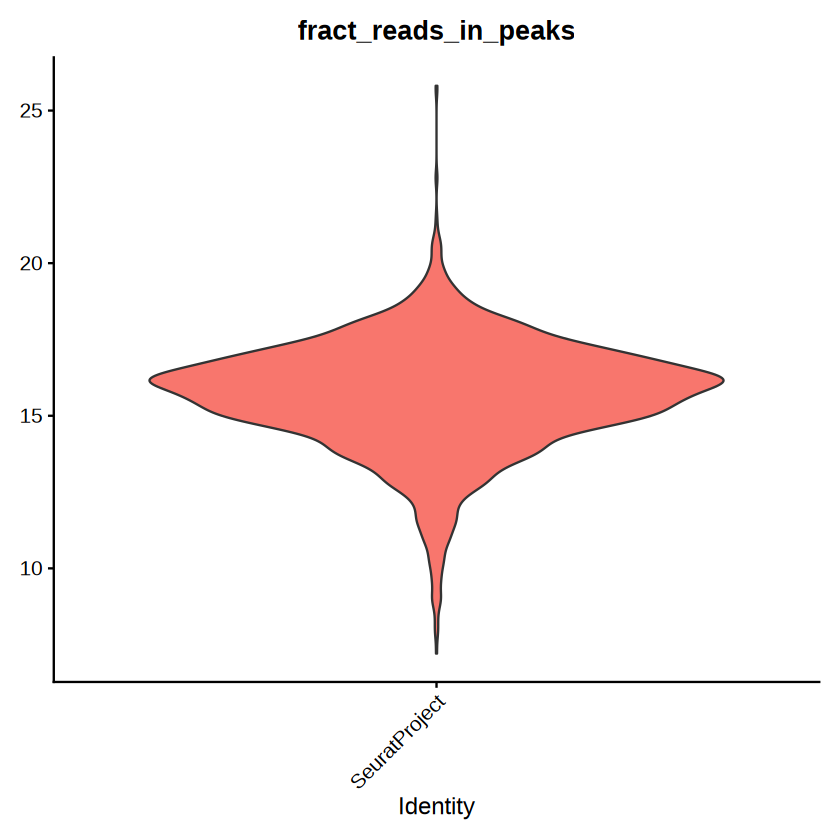

In [31]:
VlnPlot(
  object = signac_selected,
  features = c('fract_reads_in_peaks'),
  ncol = 1,
  pt.size = 0,
  group.by = "orig.ident"
  ) + NoLegend()

### 3.3.5 - Total fragments per Spot
-   Similar to fragments per cell in snATAC-seq, this measures sequencing depth per spatial location.
-   Expected distribution: A log-normal or heavy-tailed distribution.
-   Possible threshold: Spots with very low fragments (<1000) might be discarded.

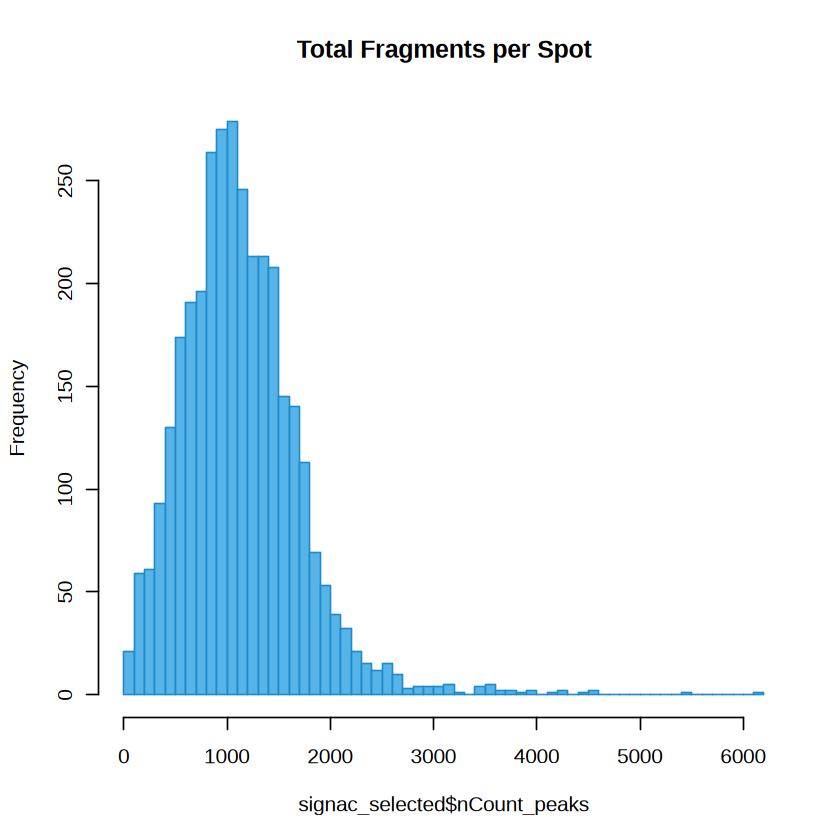

In [32]:
hist(signac_selected$nCount_peaks, breaks = 50, main = "Total Fragments per Spot", col = colors_okate[4], border = "#1f8bca")


### 3.3.5 - Other metrics

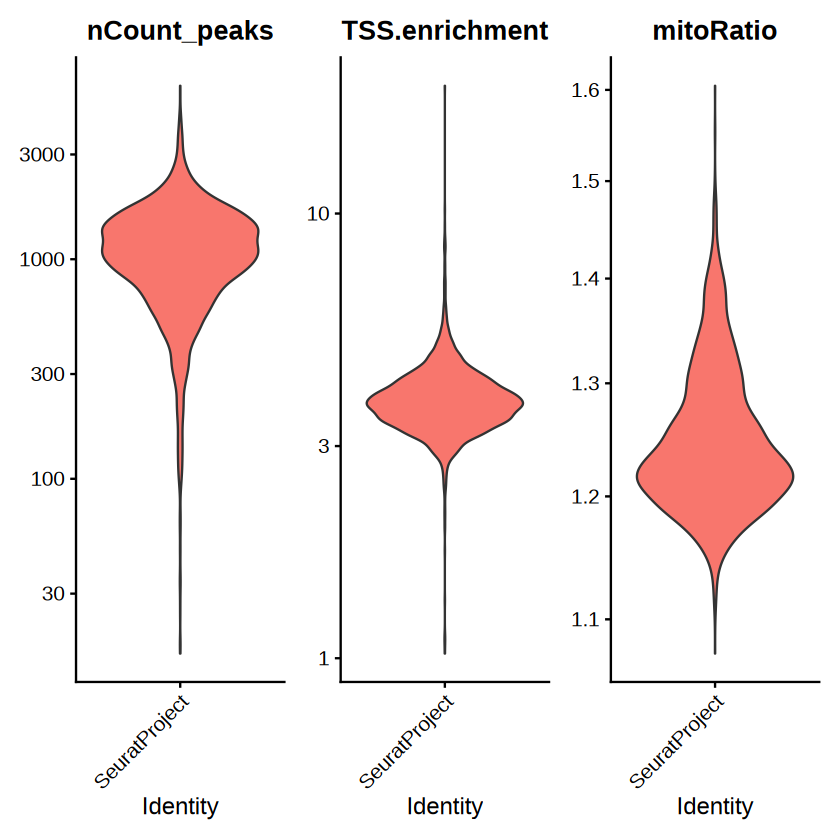

In [33]:
VlnPlot(signac_selected, features = c('nCount_peaks', 'TSS.enrichment', 'mitoRatio'), 
        ncol = 3, pt.size = 0, log = TRUE, group.by = "orig.ident")


---
# 4. - Computing LSI normalisation and clustering
I don't think that I should normalise once again.

In [34]:
#preprocess raw data
signac_selected <- signac_selected %>% 
  RunTFIDF() %>%
  FindTopFeatures(min.cutoff = 'q0') %>%
  RunSVD()

Performing TF-IDF normalization

Warning message in RunTFIDF.default(object = GetAssayData(object = object, layer = "counts"), :
"Some features contain 0 total counts"


Running SVD

Scaling cell embeddings



Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"font width unknown for character 0x09 in encoding latin1"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"font width unknown for character 0x09 in encoding latin1"


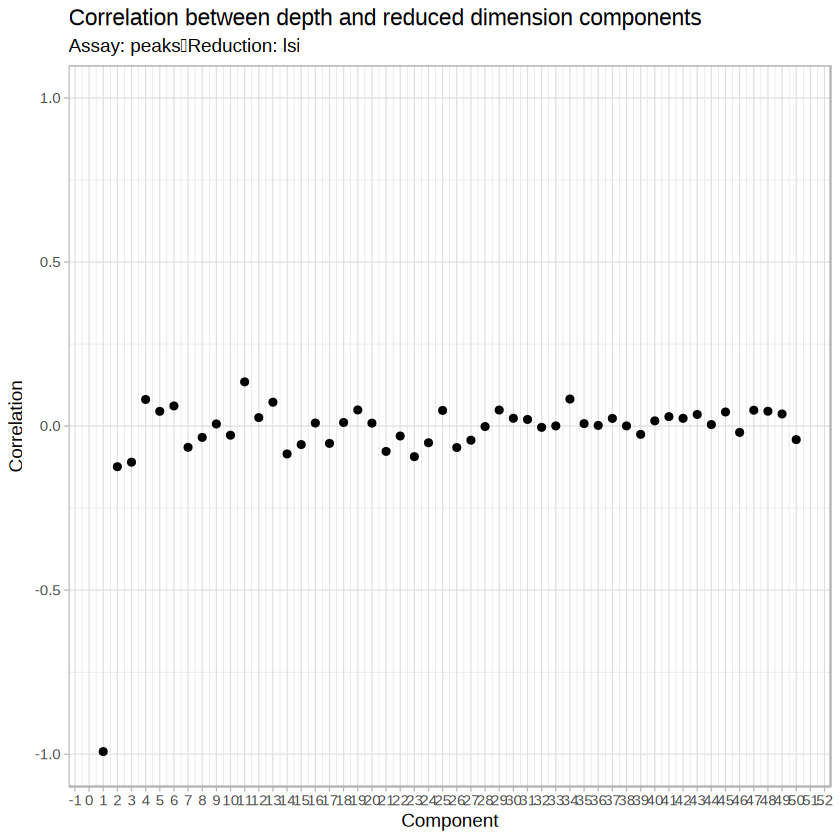

In [35]:
DepthCor(signac_selected, n = 50)

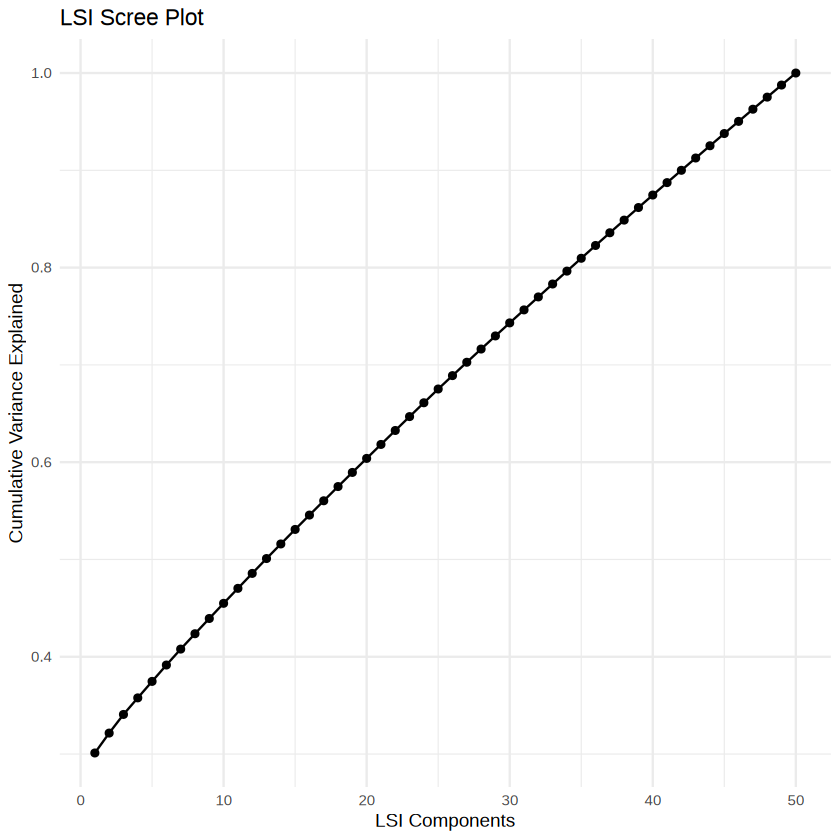

In [36]:
lsi_singular_values <- signac_selected@reductions$lsi@stdev

variance_explained <- (lsi_singular_values^2) / sum(lsi_singular_values^2)
cumulative_variance <- cumsum(variance_explained)

ggplot(data.frame(PC = 1:length(cumulative_variance), Variance = cumulative_variance), aes(x = PC, y = Variance)) +
  geom_point() + geom_line() +
  xlab("LSI Components") + ylab("Cumulative Variance Explained") +
  ggtitle("LSI Scree Plot") +
  theme_minimal()

Here we see there is a very strong correlation between the first LSI component and the total number of counts for the cell. We will perform downstream steps without this component as we don’t want to group cells together based on their total sequencing depth, but rather by their patterns of accessibility at cell-type-specific peaks.

And then they choose 7 components, while in the tutorial, they go for `2:30`.

In [37]:
signac_selected <- signac_selected %>%
  RunUMAP(reduction = 'lsi', dims = 2:30, verbose = FALSE) %>%
  FindNeighbors(reduction = 'lsi', dims = 2:30, verbose = FALSE) %>%
  FindClusters(algorithm = 4, resolution = seq(from = 0.1, to = 1.2, by = 0.1), verbose = FALSE)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"


Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clu

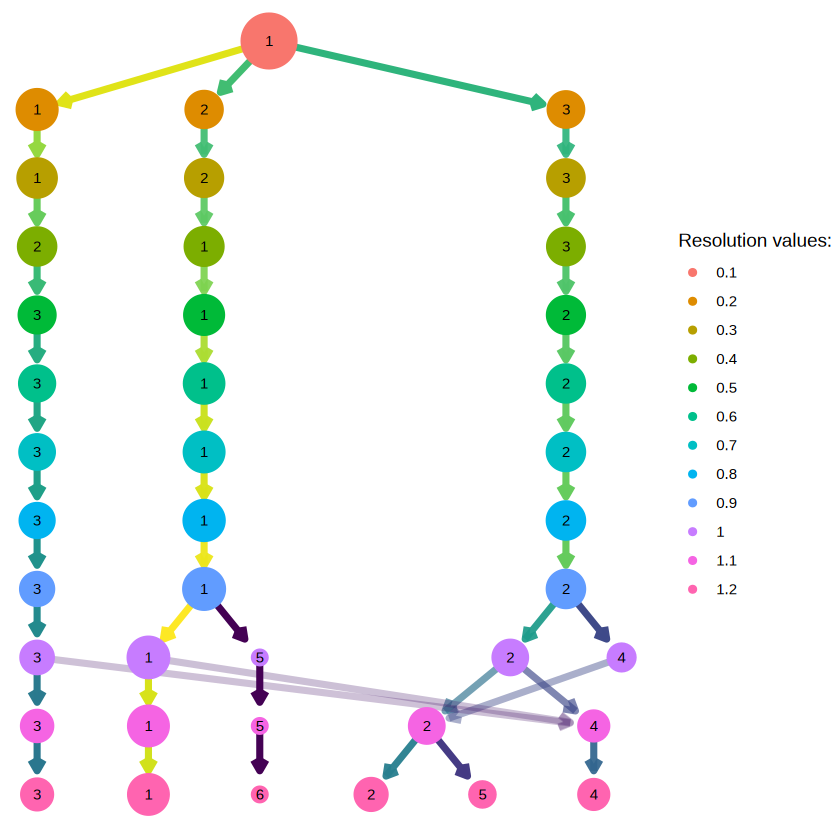

In [38]:
clustree(signac_selected, prefix = "peaks_snn_res.", node_colour_agglomerate = FALSE) + 
    guides(edge_colour = "none", edge_alpha = "none", size = "none") +
    labs(colour = "Resolution values:")

Choosing the final resolution to go for.

In [39]:
FINAL_RESOLUTION_PEAKS <- 1.0
CLUSTERING_NAME_PEAKS <- paste0("peaks_snn_res_", FINAL_RESOLUTION_PEAKS)

signac_selected <- signac_selected %>%
  RunUMAP(reduction = 'lsi', dims = 2:30, verbose = FALSE) %>%
  FindNeighbors(reduction = 'lsi', dims = 2:30, verbose = FALSE) %>%
  FindClusters(algorithm = 4, resolution = FINAL_RESOLUTION_PEAKS, verbose = FALSE, cluster.name = CLUSTERING_NAME_PEAKS)

table(signac_selected[[CLUSTERING_NAME_PEAKS]])

Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


peaks_snn_res_1
   1    2    3    4    5 
1462  854  687  327    2 

## 4.1 - Plotting by clusters

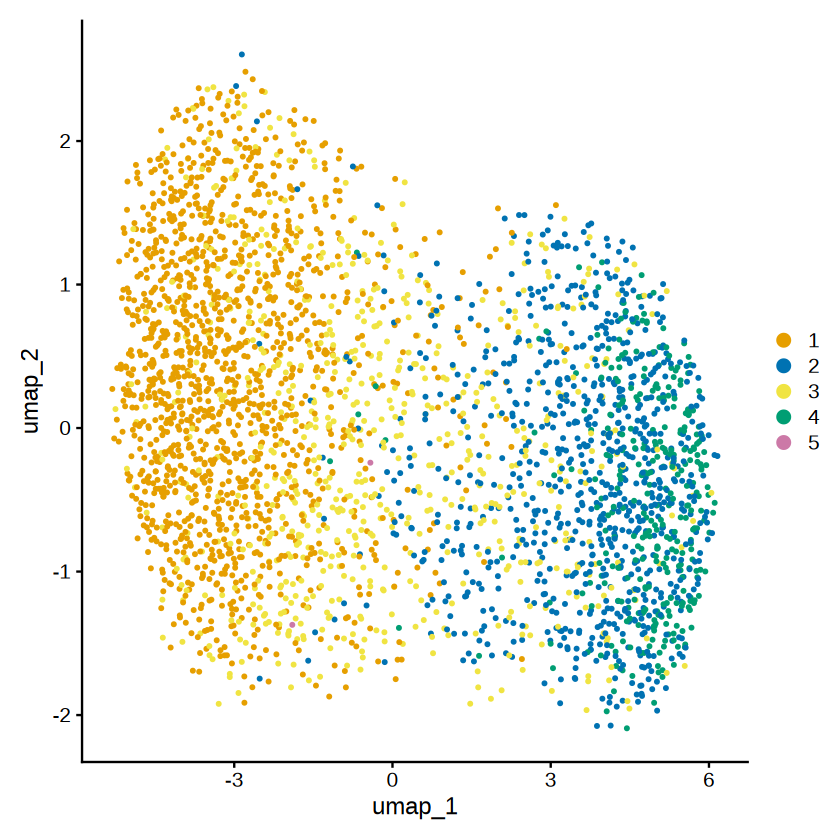

In [40]:
new_colors_okate_6 <- c("#E69F00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#D55E00")
new_colors_okate_7 <- c(new_colors_okate_6, "#612e07")

DimPlot(object = signac_selected, reduction = "umap", cols = new_colors_okate_7,
 label = FALSE)# + NoLegend()

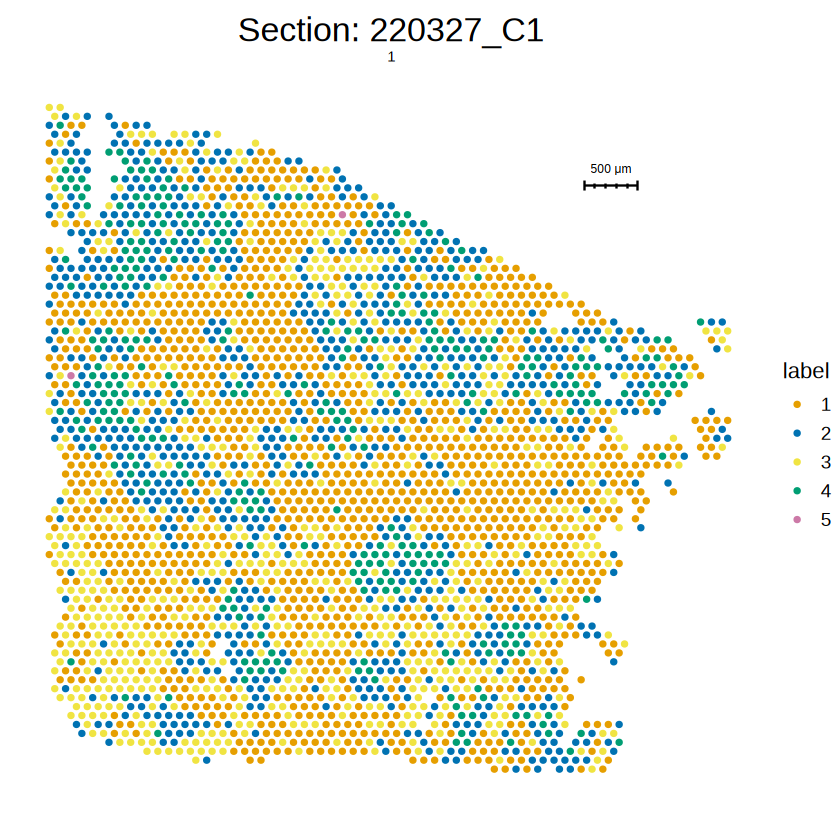

In [41]:
for (sec in unique(signac_selected$section)) {
    p <- ST.FeaturePlot(subset(signac_selected, section == sec), 
                        features = "seurat_clusters", 
                        #cols = colors_okate,
                        # cols = new_colors_okate_6,
                        cols = new_colors_okate_7,
                        pt.size = 1.8) +
         ggtitle(paste("Section:", sec)) +
         theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(),  # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13))
    
    print(p)  # Display the plot
    plot_file_name <- paste0(PATH_TO_FIGURES_SATAC, "Cluster_plot_for_selected_", sec, "_just_atac.png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)
}

## 4.2 - Plotting by chromatin accessibility

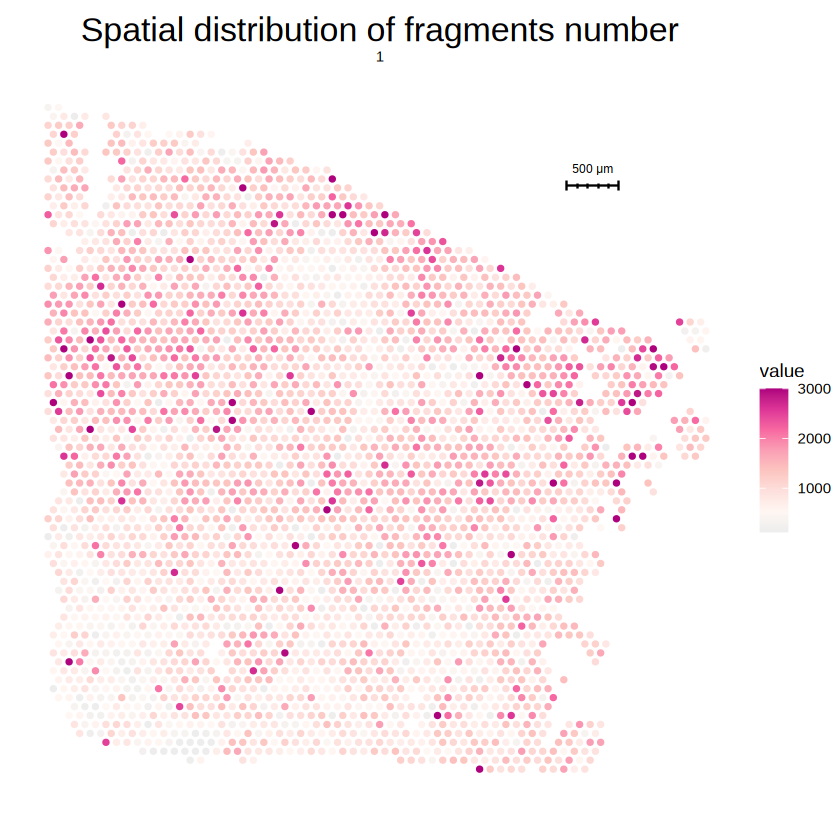

In [42]:
DefaultAssay(signac_selected) <- 'peaks'

ST.FeaturePlot(signac_selected, 
                'nCount_peaks', 
                cols = magenta_scale,
                min.cutoff = 'q1', 
                max.cutoff = 'q99',
                pt.size = 1.8, indices = 1) +
        # ggtitle(paste("Section:", signac_selected$section, "- spatial distribution of fragments number")) +
        ggtitle(paste("Spatial distribution of fragments number")) +
        #  theme(plot.title = element_text(hjust = 0.5, size = 16))
         theme(plot.title = element_text(hjust = 0.5, size = 20))

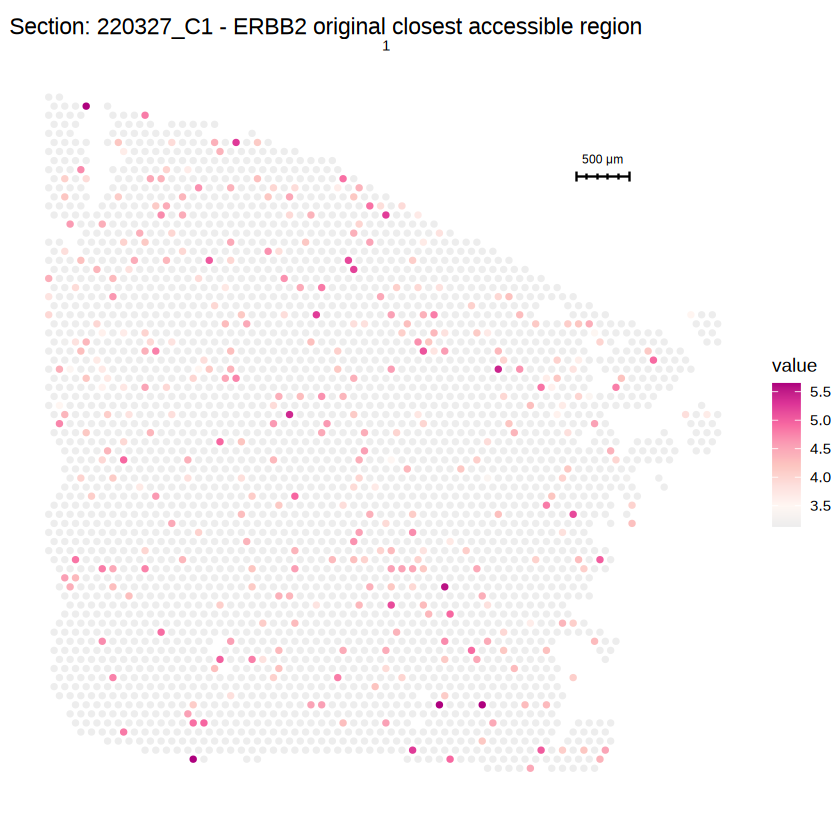

In [43]:
# grep("chr17-397", rownames(signac_selected), value = TRUE)

ST.FeaturePlot(signac_selected, 
                'chr17-39699726-39700227', 
                cols = magenta_scale,
                min.cutoff = 'q1', 
                max.cutoff = 'q99',
                pt.size = 1.8, indices = 1) +
        ggtitle(paste("Section:", signac_selected$section, "- ERBB2 original closest accessible region"))

    # plot_file_name <- paste0(PATH_TO_FIGURES_SATAC, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)


## 4.3 - Saving the normalised output

in the original code they use `data`, which is the normalised matrix.

In [44]:
# # #save normalised data matrix for denoising
# write.csv(signac_selected@assays$peaks@data,
#         paste0("./output/sATAC_preprocessing/data_signac_", SELECTED_sATAC_SAMPLE, "_selected_brca_q0_peak_bc_matrix2.csv"))
# write.csv(signac_selected@assays$peaks@counts,
#         paste0("./output/sATAC_preprocessing/counts_signac_", SELECTED_sATAC_SAMPLE, "_selected_brca_q0_peak_bc_matrix2.csv"))

Save the R session as `.RDS` file.

In [45]:
# saveRDS(signac_selected, paste0(PATH_TO_sATAC_PREPROCESSING_OUTPUT, "1_cross_mod_selected_", SELECTED_sATAC_SAMPLE, "_brca.rds"))

---
# - NOTE -

In this Notebook, the peaks denoising is skipped as it does not perform properly. Refer to `cross_modality_correct_object_creation.ipynb` for that part.

---
# 5. - Gene activity

In [46]:
# signac_selected <- readRDS("output/sATAC_preprocessing/filtered_compared_brca_denoised_peaks.rds")

In [47]:
# calculate gene activity
DefaultAssay(signac_selected) <- "peaks"
# annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
# seqlevelsStyle(annotations) <- 'UCSC'
# Annotation(signac_selected) <- annotations
gene.activities <- GeneActivity(signac_selected)

Extracting gene coordinates

Warning message in SingleFeatureMatrix(fragment = fragments[[x]], features = features, :
"13 features are on seqnames not present in the fragment file. These will be removed."
Extracting reads overlapping genomic regions



In [48]:
# add the gene activity matrix to the Seurat object as a new assay and normalize it
#remove PCDH and UGT genes
gene.activities <- gene.activities[-grep("PCDH", rownames(gene.activities)),]
gene.activities <- gene.activities[-grep("UGT", rownames(gene.activities)),]
signac_selected[['RNA']] <- CreateAssayObject(counts = gene.activities)

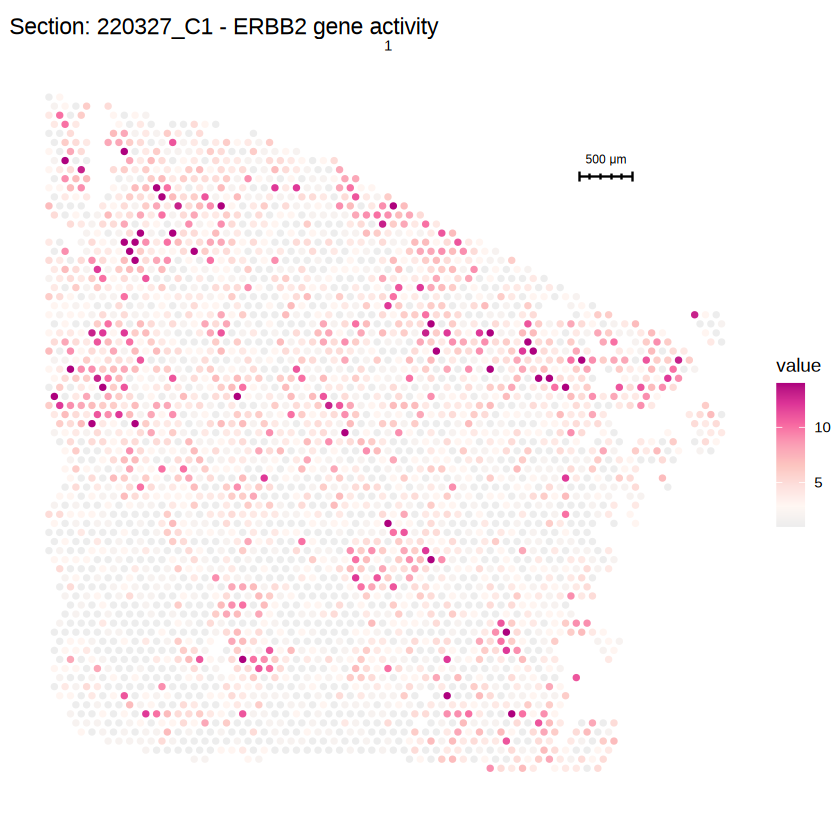

In [49]:
# grep("chr17-397", rownames(signac_selected), value = TRUE)
DefaultAssay(signac_selected) <- "RNA"

ST.FeaturePlot(signac_selected, 
                'ERBB2', # from paper
                cols = magenta_scale,
                min.cutoff = 'q1', 
                max.cutoff = 'q99',
                pt.size = 1.8, indices = 1) +
        ggtitle(paste("Section:", signac_selected$section, "- ERBB2 gene activity"))

    # plot_file_name <- paste0(PATH_TO_FIGURES_SATAC, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)

In [50]:
DefaultAssay(signac_selected) <- "RNA"
signac_selected <- signac_selected %>%
  NormalizeData(verbose = FALSE) %>%
  FindVariableFeatures(verbose = FALSE) %>%
  ScaleData(verbose = FALSE) %>%
  RunPCA(verbose = FALSE) %>%
  RunUMAP(dims = 1:30, verbose = FALSE) %>%
  FindNeighbors(dims = 1:30, verbose = FALSE) %>%
  FindClusters(algorithm = 4, resolution = seq(from = 0.1, to = 1.2, by = 0.1), verbose = FALSE)

Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clu

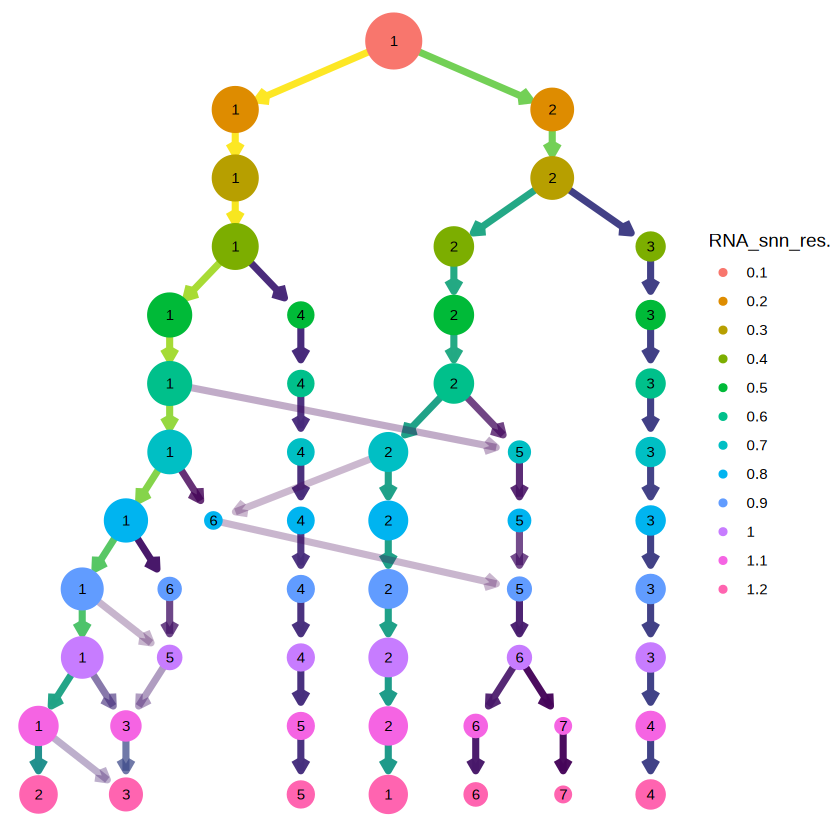

In [51]:
clustree(signac_selected, prefix = "RNA_snn_res.", node_colour_agglomerate = FALSE) + 
    guides(edge_colour = "none", edge_alpha = "none", size = "none")

Choosing the right number of clusters.

In [52]:
DefaultAssay(signac_selected) <- "RNA"

signac_selected <- signac_selected %>%
  NormalizeData(verbose = FALSE) %>%
  FindVariableFeatures(verbose = FALSE) %>%
  ScaleData(verbose = FALSE) %>%
  RunPCA(verbose = FALSE)

In [53]:
final_resolution_RNA <- 0.6
clustering_name_RNA <- paste0("RNA_snn_res_", final_resolution_RNA)

signac_selected <- signac_selected %>%
  RunUMAP(dims = 1:30, verbose = FALSE) %>%
  FindNeighbors(dims = 1:30, verbose = FALSE) %>%
  FindClusters(algorithm = 4, resolution = final_resolution_RNA, cluster.name = clustering_name_RNA, verbose = FALSE)

table(signac_selected[[clustering_name_RNA]])

Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


RNA_snn_res_0.6
   1    2    3    4 
1615 1135  359  223 

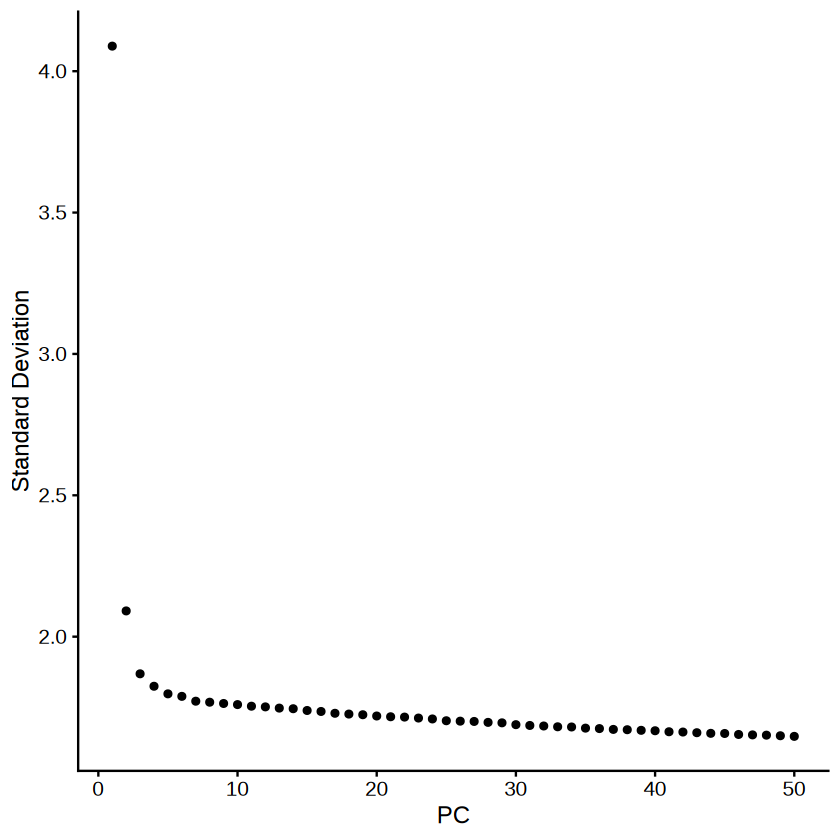

In [54]:
ElbowPlot(signac_selected, n = 50)

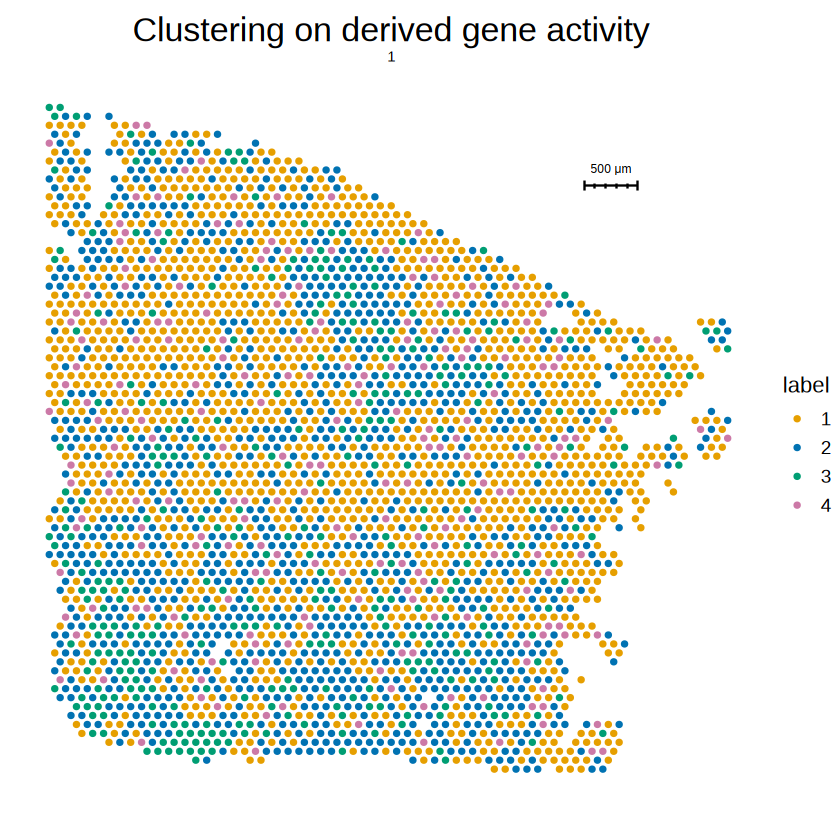

In [55]:
new2_colors_okate_5 <- c('#E69F00', '#0072B2', '#009E73', '#CC79A7', '#F0E442', '#D55E00')

for (sec in unique(signac_selected$section)) {
    p <- ST.FeaturePlot(subset(signac_selected, section == sec), 
                        features = clustering_name_RNA, 
                        # cols = colors_okate,
                        cols = new2_colors_okate_5,
                        pt.size = 1.8) +
         ggtitle(paste("Clustering on derived gene activity")) +
         theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(),  # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13))
    
    print(p)  # Display the plot
    # plot_file_name <- paste0(PATH_TO_FIGURES_SATAC, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)
}

Clustering with K-Means.

In [56]:
signac_selected[["kmeans_6_rna_act"]] <- kmeans(signac_selected@reductions$pca@cell.embeddings[1:30], 6, algorithm = "Lloyd", iter.max = 300)$cluster
signac_selected$kmeans_6_rna_act <- as.factor(signac_selected$kmeans_6_rna_act)

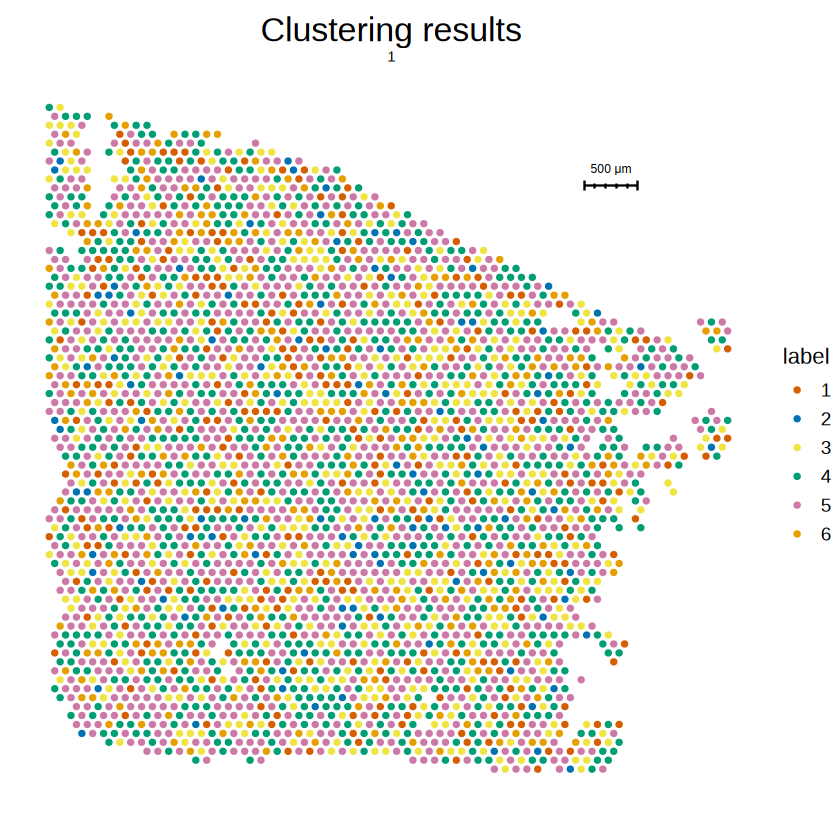

In [57]:
ST.FeaturePlot(signac_selected, 
                features = "kmeans_6_rna_act", 
                cols = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00"),
                pt.size = 1.8) +
              ggtitle("Clustering results") +
              theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(), # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13)) #+
              # scale_fill_manual(values = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00"),
              #   name = "Cluster")

In [ ]:
# write.csv(signac_selected@assays$RNA@counts, paste0(PATH_TO_sATAC_PREPROCESSING_OUTPUT, "gene_activity_selected_", SELECTED_sATAC_SAMPLE, "_brca.csv"))
# write.csv(signac_selected@assays$RNA@counts, paste0(PATH_TO_sATAC_PREPROCESSING_OUTPUT, "gene_activity_selected_", SELECTED_sATAC_SAMPLE, "_brca_overlapping.csv"))

## 5.1 - DCA for gene activity
Run DCA on terminal
```sh
nohup dca output/sATAC_preprocessing/gene_activity_selected_<SAMPLE_NAME>_brca.csv output/sATAC_preprocessing/dca_gene_activity_selected_<SAMPLE_NAME>_brca --threads 6 --saveweights > nohup_for_<SAMPLE_NAME>_dca_gene_activity.out &
```

In [59]:
signac_selected

An object of class Seurat 
235500 features across 3332 samples within 2 assays 
Active assay: RNA (19522 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: peaks
 3 dimensional reductions calculated: lsi, umap, pca

In [62]:
# gene activity
# signac_selected[["dca"]] <- NULL
# mtx <- read.table(paste0(PATH_TO_sATAC_PREPROCESSING_OUTPUT, "dca_gene_activity_selected_", SELECTED_sATAC_SAMPLE, "_brca/mean.tsv"))
mtx <- read.table(paste0(PATH_TO_sATAC_PREPROCESSING_OUTPUT, "dca_gene_activity_selected_", SELECTED_sATAC_SAMPLE, "_brca_overlapping/mean.tsv"))
colnames(mtx) <- gsub("\\.", "-", colnames(mtx))

In [63]:
DefaultAssay(signac_selected) <- "RNA"
signac_selected <- subset(signac_selected, cells = colnames(mtx))

# add denoised matrix to object
signac_selected[["RNA_dca"]] <- CreateAssayObject(counts = as.matrix(mtx))
rm(mtx)

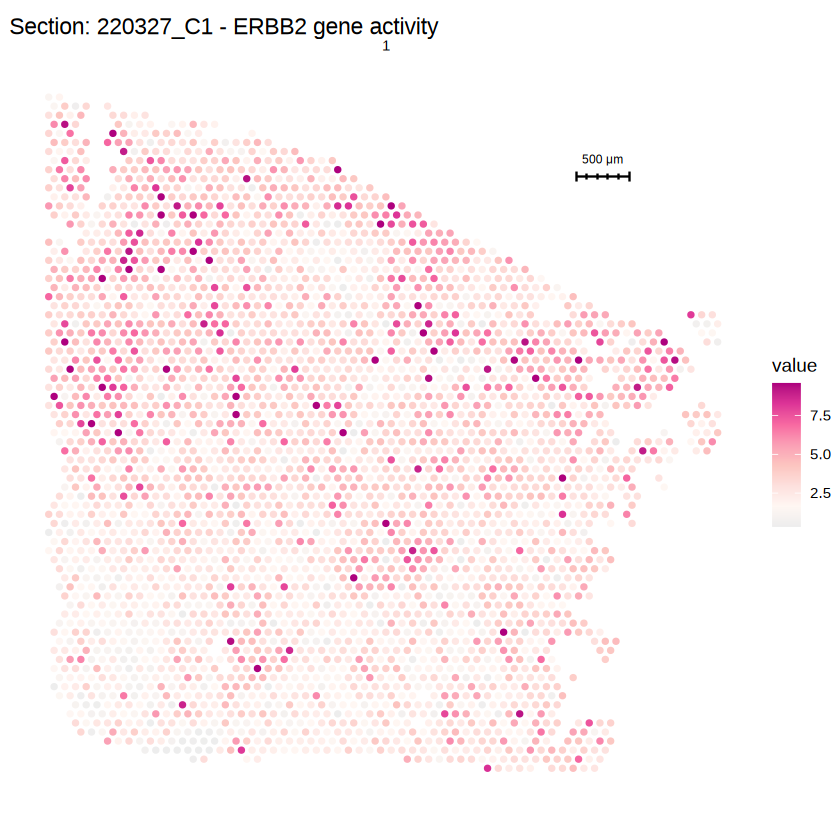

In [64]:
# grep("chr17-397", rownames(signac_selected), value = TRUE)
DefaultAssay(signac_selected) <- "RNA_dca"

ST.FeaturePlot(signac_selected, 
                # 'CD68', # from paper
                'ERBB2', # from paper
                cols = magenta_scale,
                min.cutoff = 'q1', 
                max.cutoff = 'q99',
                pt.size = 1.8, indices = 1) +
        ggtitle(paste("Section:", signac_selected$section, "- ERBB2 gene activity"))
        # ggtitle(paste("Section:", signac_selected$section, "- CD68 gene activity"))

    # plot_file_name <- paste0(PATH_TO_FIGURES_SATAC, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)


Peaks to check:
-   *chr17-7579491-7582111* -> [CD68](http://www.ensembl.org/Homo_sapiens/Gene/Summary?g=ENSG00000129226;r=17:7579491-7582111)
-   

In [65]:
# print(Annotation(signac_selected)[grep("CD68", Annotation(signac_selected)$gene_name)])
# print(Annotation(signac_selected)[grep("chr17-7579491-7579726", Annotation(signac_selected)$gene_name)])

In [66]:
sort(grep("chr17-757", rownames(signac_selected[["peaks"]]), value = TRUE))
sort(grep("chr17-758", rownames(signac_selected[["peaks"]]), value = TRUE))

[1] "chr17-75700380-75700881" "chr17-75701160-75701661"
 [3] "chr17-75706961-75707462" "chr17-7571485-7571986"  
 [5] "chr17-75720487-75720988" "chr17-75721106-75721607"
 [7] "chr17-75721970-75722471" "chr17-75722593-75723094"
 [9] "chr17-75723232-75723733" "chr17-7572349-7572850"  
[11] "chr17-75724245-75724746" "chr17-7572979-7573480"  
[13] "chr17-7573502-7574003"   "chr17-75747741-75748242"
[15] "chr17-75749795-75750296" "chr17-75750795-75751296"
[17] "chr17-75753610-75754111" "chr17-75754403-75754904"
[19] "chr17-75755123-75755624" "chr17-75755646-75756147"
[21] "chr17-75757451-75757952" "chr17-75758188-75758689"
[23] "chr17-75762429-75762930" "chr17-75763171-75763672"
[25] "chr17-75764089-75764590" "chr17-75764942-75765443"
[27] "chr17-75765867-75766368" "chr17-75769553-75770054"
[29] "chr17-75771943-75772444" "chr17-75772531-75773032"
[31] "chr17-75773255-75773756" "chr17-75773783-75774284"
[33] "chr17-75774787-75775288" "chr17-75776007-75776508"
[35] "chr17-75776548-75777049" "chr17-75777352-75777853"
[37] "chr17-75777942-75778443" "chr17-75778460-75778961"
[39] "chr17-75779122-75779623" "chr17-75779704-75780205"
[41] "chr17-75780471-75780972" "chr17-75781152-75781653"
[43] "chr17-75781818-75782319" "chr17-75782779-75783280"
[45] "chr17-75783336-75783837" "chr17-75783933-75784434"
[47] "chr17-75784457-75784958" "chr17-75785310-75785811"
[49] "chr17-75786333-75786834" "chr17-75786914-75787415"
[51] "chr17-75787633-75788134" "chr17-75788500-75789001"
[53] "chr17-7579309-7579810"

[1] "chr17-75806819-75807320" "chr17-75807773-75808274"
 [3] "chr17-75808978-75809479" "chr17-75809688-75810189"
 [5] "chr17-75810195-75810696" "chr17-75814844-75815345"
 [7] "chr17-7581870-7582371"   "chr17-75819022-75819523"
 [9] "chr17-75821246-75821747" "chr17-75822400-75822901"
[11] "chr17-75822944-75823445" "chr17-75823491-75823992"
[13] "chr17-75824141-75824642" "chr17-75824925-75825426"
[15] "chr17-75826554-75827055" "chr17-75827101-75827602"
[17] "chr17-7582734-7583235"   "chr17-75827744-75828245"
[19] "chr17-75828610-75829111" "chr17-75830322-75830823"
[21] "chr17-75832043-75832544" "chr17-75832843-75833344"
[23] "chr17-7583531-7584032"   "chr17-75837917-75838418"
[25] "chr17-75842225-75842726" "chr17-7584237-7584738"  
[27] "chr17-75843005-75843506" "chr17-75843547-75844048"
[29] "chr17-75844141-75844642" "chr17-75844675-75845176"
[31] "chr17-75845187-75845688" "chr17-75845795-75846296"
[33] "chr17-75846329-75846830" "chr17-75847022-75847523"
[35] "chr17-75847594-75848095" "chr17-75848581-75849082"
[37] "chr17-75849572-75850073" "chr17-75851231-75851732"
[39] "chr17-75853306-75853807" "chr17-75853952-75854453"
[41] "chr17-75854780-75855281" "chr17-75855282-75855783"
[43] "chr17-75855855-75856356" "chr17-75856604-75857105"
[45] "chr17-75861238-75861739" "chr17-75864374-75864875"
[47] "chr17-7586666-7587167"   "chr17-75869176-75869677"
[49] "chr17-75869692-75870193" "chr17-75870234-75870735"
[51] "chr17-75871387-75871888" "chr17-75872727-75873228"
[53] "chr17-75873437-75873938" "chr17-75874177-75874678"
[55] "chr17-75874696-75875197" "chr17-75875311-75875812"
[57] "chr17-75875911-75876412" "chr17-75876500-75877001"
[59] "chr17-75877191-75877692" "chr17-75877749-75878250"
[61] "chr17-7587787-7588288"   "chr17-75878375-75878876"
[63] "chr17-75879167-75879668" "chr17-75888554-75889055"
[65] "chr17-7589217-7589718"   "chr17-75893990-75894491"
[67] "chr17-75894629-75895130" "chr17-75895677-75896178"
[69] "chr17-75896280-75896781" "chr17-75896784-75897285"
[71] "chr17-75897583-75898084" "chr17-75898579-75899080"
[73] "chr17-7589892-7590393"   "chr17-75899578-75900079"

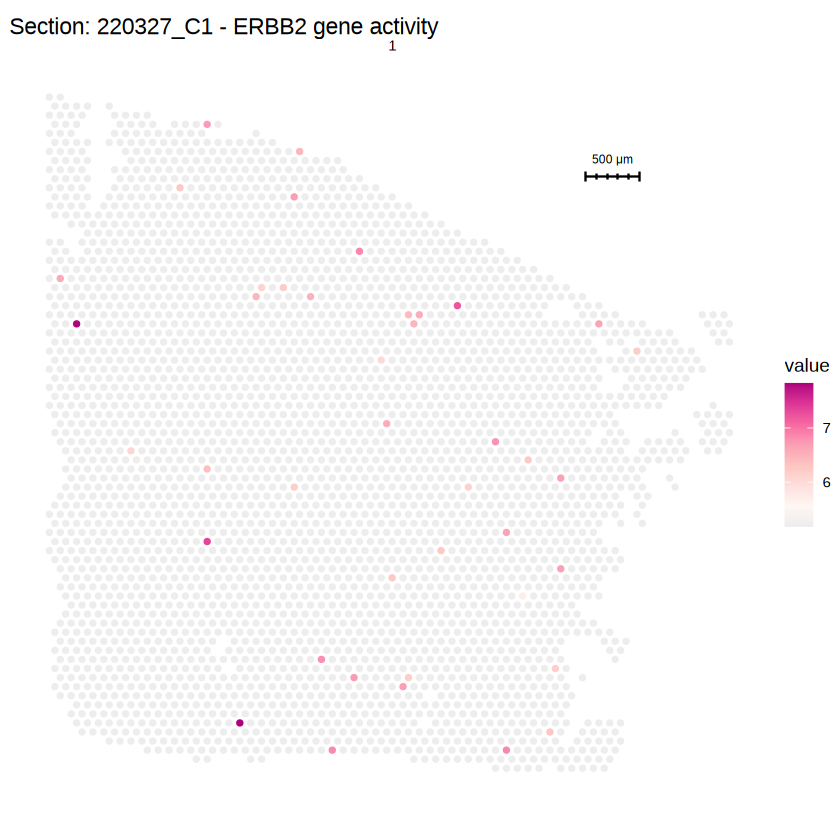

In [67]:
# grep("chr17-397", rownames(signac_selected), value = TRUE)
DefaultAssay(signac_selected) <- "peaks"

ST.FeaturePlot(signac_selected, 
                'chr1-22652746-22653247', # from paper - regulatory region
                # 'chr17-7579491-7579726', # 
                cols = magenta_scale,
                min.cutoff = 'q1', 
                max.cutoff = 'q99',
                pt.size = 1.8, indices = 1) +
        ggtitle(paste("Section:", signac_selected$section, "- ERBB2 gene activity"))

    # plot_file_name <- paste0(PATH_TO_FIGURES_SATAC, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)


In [68]:
signac_selected

An object of class Seurat 
254813 features across 3332 samples within 3 assays 
Active assay: peaks (215978 features, 215978 variable features)
 2 layers present: counts, data
 2 other assays present: RNA, RNA_dca
 3 dimensional reductions calculated: lsi, umap, pca

## 5.2 - Clustering for gene denoised gene activity

In [69]:
DefaultAssay(signac_selected) <- "RNA_dca"

signac_selected <- signac_selected %>%
  NormalizeData(verbose = FALSE) %>%
  FindVariableFeatures(verbose = FALSE) %>%
  ScaleData(verbose = FALSE) %>%
  RunPCA(verbose = FALSE) %>%
  RunUMAP(dims = 1:30, verbose = FALSE) %>%
  FindNeighbors(dims = 1:30, verbose = FALSE) %>%
  FindClusters(algorithm = 4, resolution = seq(from = 0.1, to = 1.2, by = 0.1), verbose = FALSE)


Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."
Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clu

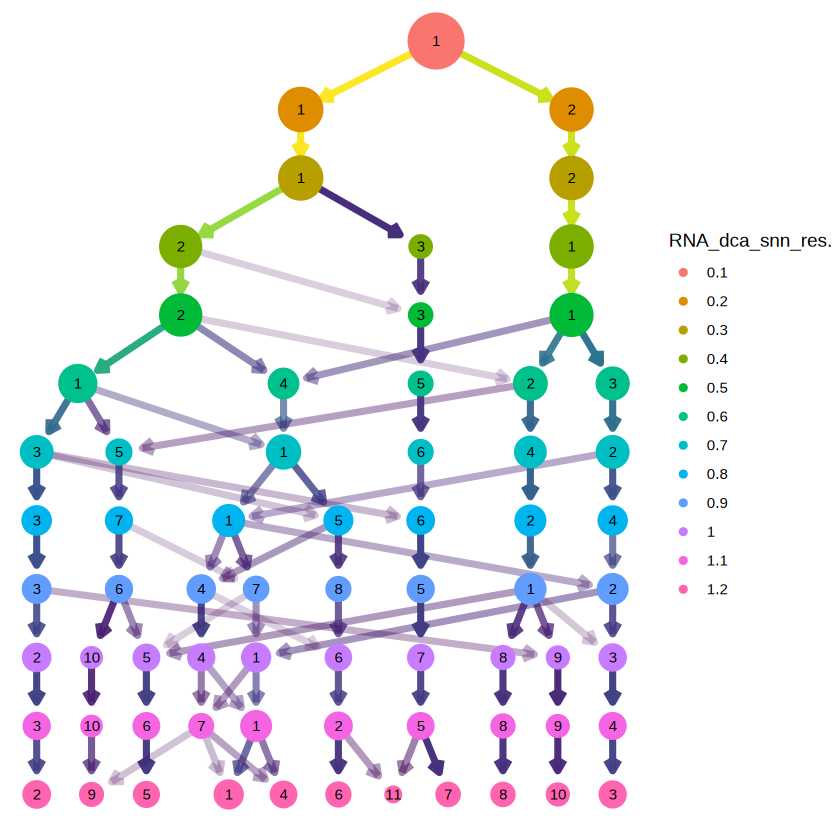

In [70]:
  clustree(signac_selected, prefix = "RNA_dca_snn_res.", node_colour_agglomerate = FALSE) + 
    guides(edge_colour = "none", edge_alpha = "none", size = "none")

Choosing the right number of clusters.

In [71]:
DefaultAssay(signac_selected) <- "RNA_dca"

signac_selected <- signac_selected %>%
  NormalizeData(verbose = FALSE) %>%
  FindVariableFeatures(verbose = FALSE) %>%
  ScaleData(verbose = FALSE) %>%
  RunPCA(verbose = FALSE)

In [72]:
FINAL_RESOLUTION_DENOISED_RNA <- 0.6
CLUSTERING_NAME_DENOISED_RNA <- paste0("RNA_dca_snn_res_", FINAL_RESOLUTION_DENOISED_RNA)

signac_selected <- signac_selected %>%
  RunUMAP(dims = 1:30, verbose = FALSE) %>%
  FindNeighbors(dims = 1:30, verbose = FALSE) %>%
  FindClusters(algorithm = 4, resolution = FINAL_RESOLUTION_DENOISED_RNA, cluster.name = CLUSTERING_NAME_DENOISED_RNA, verbose = FALSE)

table(signac_selected[[CLUSTERING_NAME_DENOISED_RNA]])

Warning message in RunLeiden(object = object, method = method, partition.type = "RBConfigurationVertexPartition", :
"`random.seed` must be greater than 0 for leiden clustering, resetting `random.seed` to 1."


RNA_dca_snn_res_0.6
   1    2    3    4    5 
1085  739  691  539  278 

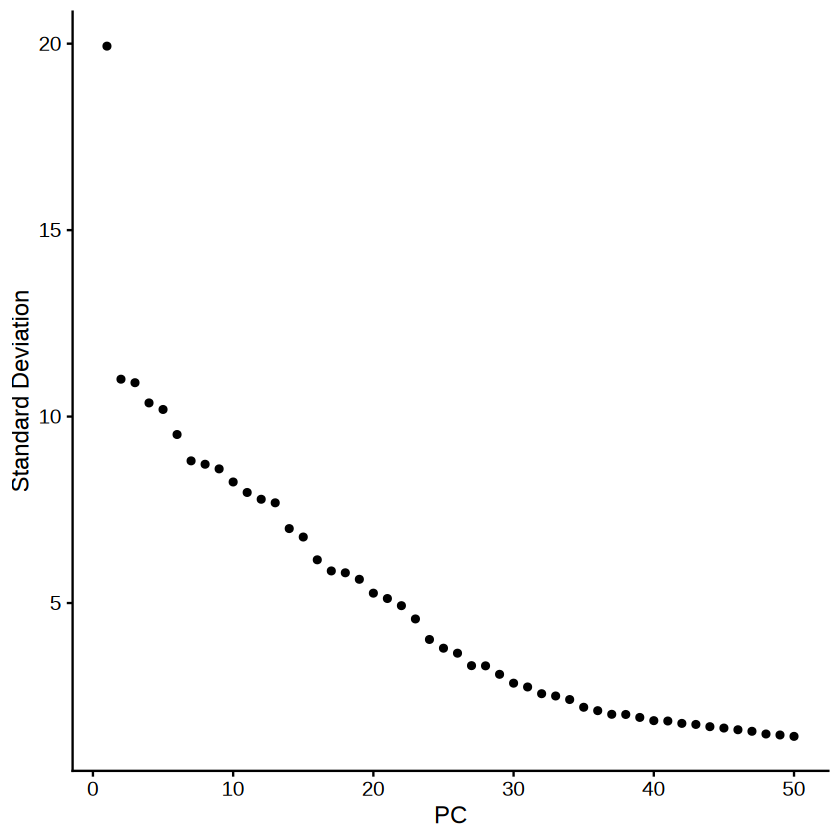

In [73]:
ElbowPlot(signac_selected, n = 50)

In [74]:
new_colors_okate_7 <- c(new_colors_okate_6, "#612e07")
new_colors_okate_7

[1] "#E69F00" "#0072B2" "#F0E442" "#009E73" "#CC79A7" "#D55E00" "#612e07"

In [75]:
DefaultAssay(signac_selected) <- "RNA_dca"

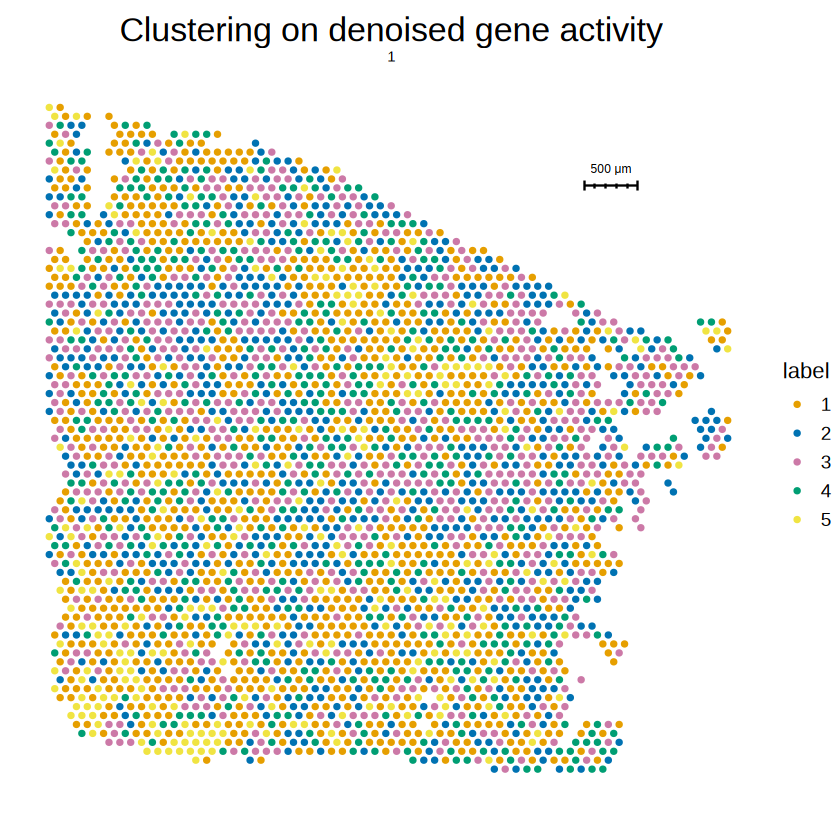

In [76]:
for (sec in unique(signac_selected$section)) {
    p <- ST.FeaturePlot(subset(signac_selected, section == sec), 
                        features = CLUSTERING_NAME_DENOISED_RNA, 
                        cols = c('#E69F00','#0072B2','#CC79A7','#009E73','#F0E442','#D55E00','#612e07'),
                        # cols = new_colors_okate_7,
                        pt.size = 1.8) +
         ggtitle(paste("Clustering on denoised gene activity")) +
         theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(),  # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13))
    
    print(p)  # Display the plot
    # plot_file_name <- paste0(PATH_TO_FIGURES_SATAC, "Cluster_plot_for_selected_", sec, ".png")
    # ggsave(filename = plot_file_name, plot = p, width = 5, height = 5, dpi = 300)
}

Clustering with K-means.

In [77]:
signac_selected[["kmeans_6_rna_act_dca"]] <- kmeans(signac_selected@reductions$pca@cell.embeddings, 6, algorithm = "Lloyd", iter.max = 300)$cluster
signac_selected$kmeans_6_rna_act_dca <- as.factor(signac_selected$kmeans_6_rna_act_dca)

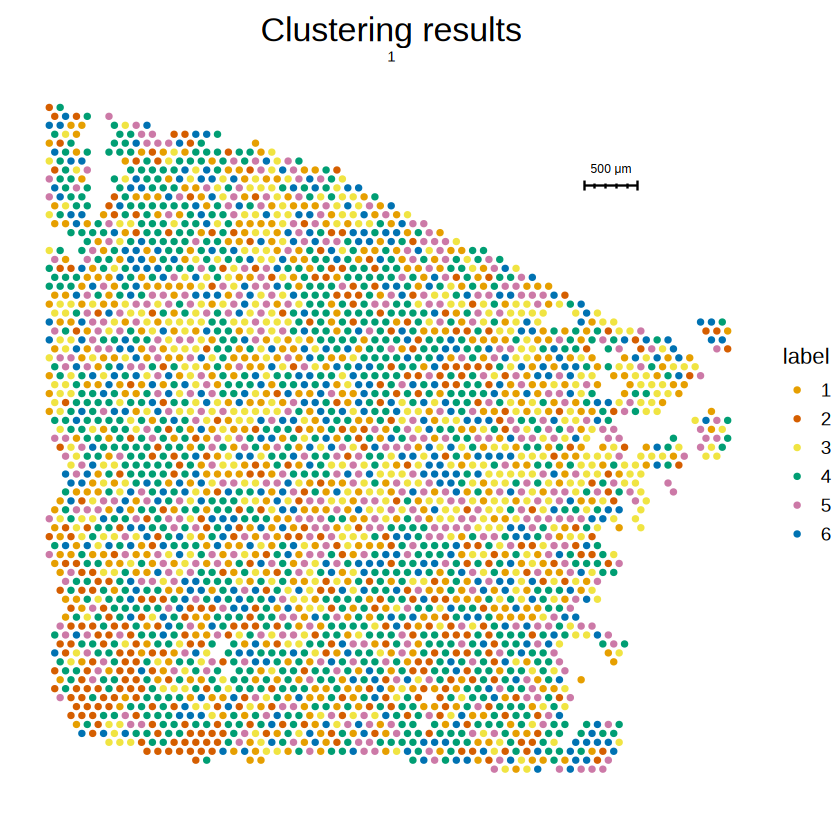

In [78]:
ST.FeaturePlot(signac_selected, 
                features = "kmeans_6_rna_act_dca", 
                cols = c("#E69F00", "#D55E00", "#F0E442", "#009E73", "#CC79A7", "#0072B2"),
                pt.size = 1.8) +
              ggtitle("Clustering results") +
              theme(plot.title = element_text(hjust = 0.5, size = 20), # ,family = "DM Sans Medium"
                plot.subtitle = element_blank(), # Remove subtitle (if that's the small number))
                legend.text = element_text(size = 11),
                legend.title = element_text(size = 13)) #+
              # scale_fill_manual(values = c("#D55E00", "#0072B2", "#F0E442", "#009E73", "#CC79A7", "#E69F00"),
              #   name = "Cluster")

---

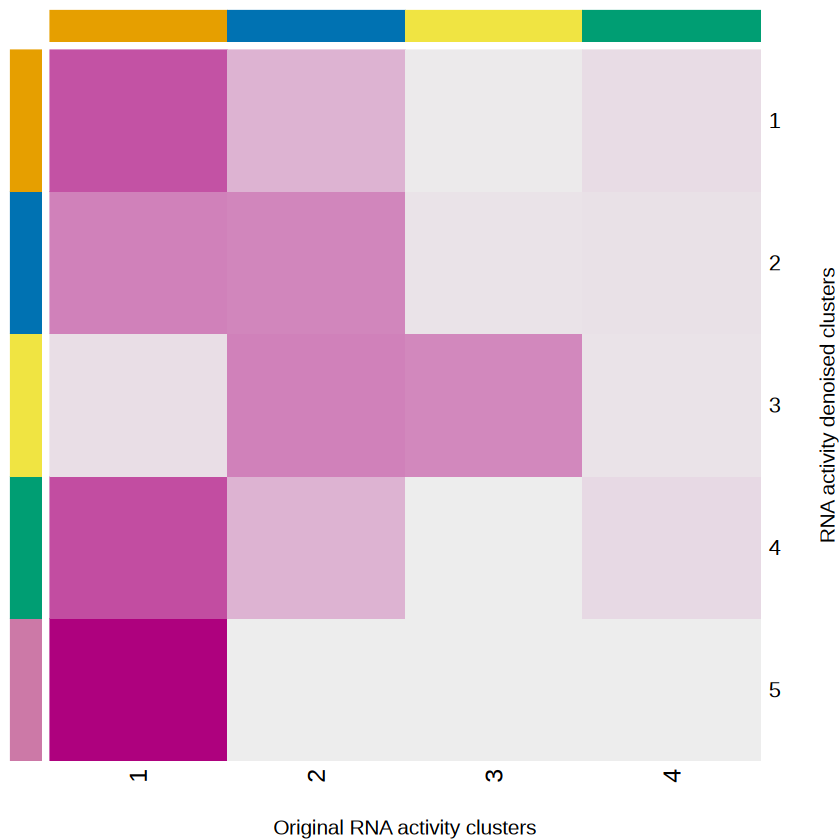

In [79]:
# Check the proportion of spots assigned to each cluster when using denoised vs original data
prop <- prop.table(table(signac_selected@meta.data[[CLUSTERING_NAME_PEAKS]], signac_selected@meta.data[[clustering_name_RNA]]), 1)*100

# Ensure colors match the number of clusters
row_colors <- rev(new_colors_okate_6[1 : nrow(prop)])
col_colors <- new_colors_okate_6[1 : ncol(prop)]

heatmap(prop[order(nrow(prop):1),], 
        Colv = NA, Rowv = NA, scale="none", 
        xlab="Original RNA activity clusters", ylab="RNA activity denoised clusters", 
        col = hm_colors, 
        RowSideColors = row_colors, 
        ColSideColors = col_colors)

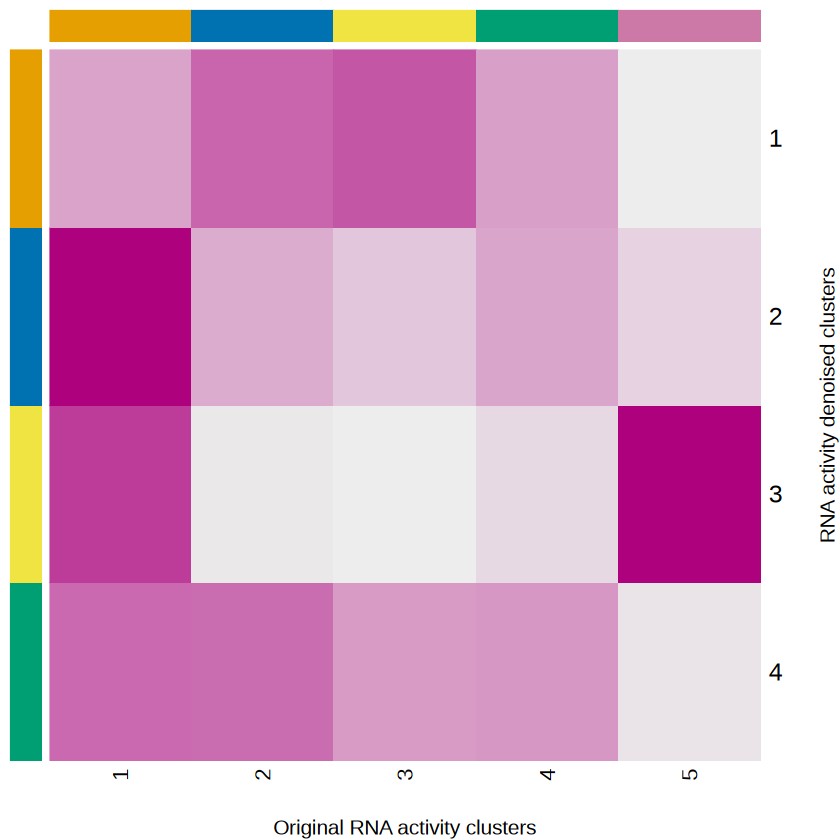

In [80]:
# Check the proportion of spots assigned to each cluster when using denoised vs original data
prop <- prop.table(table(signac_selected@meta.data[[clustering_name_RNA]], signac_selected@meta.data[[CLUSTERING_NAME_DENOISED_RNA]]), 1)*100

# Ensure colors match the number of clusters
row_colors <- rev(new_colors_okate_6[1 : nrow(prop)])
col_colors <- new_colors_okate_6[1 : ncol(prop)]

heatmap(prop[order(nrow(prop):1),], 
        Colv = NA, Rowv = NA, scale="none", 
        xlab="Original RNA activity clusters", ylab="RNA activity denoised clusters", 
        col = hm_colors, 
        RowSideColors = row_colors, 
        ColSideColors = col_colors)

In [81]:
# saveRDS(signac_selected, paste0(PATH_TO_sATAC_PREPROCESSING_OUTPUT, "4_cross_mod_selected_", SELECTED_sATAC_SAMPLE, "_brca_denoised_RNA_from_satac_part.rds"))

---
# 6. - Comparison with scRNA-seq


## 6.1 - Creating the initial single cell object

Remeber to change the names of the files inside the scRNA-seq folder.

Downloaded from: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE176078

```sh
wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176078/suppl/GSE176078%5FWu%5Fetal%5F2021%5FBRCA%5FscRNASeq%2Etar%2Egz
```

And remember to change the names of the files:
```sh
mv count_matrix_barcodes.tsv barcodes.tsv
mv count_matrix_genes.tsv genes.tsv
mv count_matrix_sparse.mtx matrix.mtx
```

In [82]:
# compare sATAC with scRNA-seq
## scRNA-seq atlas of BRCA obtained from https://www.nature.com/articles/s41588-021-00911-1
meta_sc <- read.csv("../data/Wu_etal_2021_BRCA_scRNASeq/metadata.csv", row.names = 1)
mtx <- Read10X("../data/Wu_etal_2021_BRCA_scRNASeq/", gene.column = 1)

In [83]:
# preprocess single cell data
sc_obj <- CreateSeuratObject(mtx, meta.data = meta_sc, min.cells = 3, min.features = 200) 
print(sc_obj)
dim(sc_obj)
table(sc_obj$orig.ident)
table(sc_obj$celltype_major)
sc_obj[["percent.mt"]] <- PercentageFeatureSet(sc_obj, pattern = "^MT-")

# plot1 <- FeatureScatter(sc_obj, feature1 = "nCount_RNA", feature2 = "percent.mt") + NoLegend()
# plot2 <- FeatureScatter(sc_obj, feature1 = "nCount_RNA", feature2 = "nFeature_RNA") + NoLegend()
# plot1
# plot2

An object of class Seurat 
27719 features across 100064 samples within 1 assay 
Active assay: RNA (27719 features, 0 variable features)
 1 layer present: counts


[1]  27719 100064


 CID3586  CID3838  CID3921  CID3941  CID3946  CID3948  CID3963  CID4040 
    6178     2353     3024      631      774     2327     3527     2531 
 CID4066  CID4067 CID4290A  CID4398 CID44041  CID4461  CID4463  CID4465 
    5309     3764     5789     4451     2131      631     1138     1564 
 CID4471  CID4495 CID44971 CID44991  CID4513  CID4515 CID45171  CID4523 
    8609     7985     7986     7023     5619     4149     2447     1754 
CID4530N  CID4535 
    4409     3961 


          B-cells              CAFs Cancer Epithelial       Endothelial 
             3206              6573             24489              7605 
          Myeloid Normal Epithelial      Plasmablasts               PVL 
             9675              4355              3524              5423 
          T-cells 
            35214 

In [84]:
sc_obj <- subset(sc_obj, subset = nFeature_RNA > 300 & nFeature_RNA < 8000 & percent.mt < 10)
dim(sc_obj)
table(sc_obj$celltype_major)

[1] 27719 82954


          B-cells              CAFs Cancer Epithelial       Endothelial 
             2780              5924             14682              6498 
          Myeloid Normal Epithelial      Plasmablasts               PVL 
             8808              3159              3185              4539 
          T-cells 
            33379 

In [85]:
sc_obj <- sc_obj %>%
  NormalizeData(verbose = FALSE) %>%
  FindVariableFeatures(verbose = FALSE) %>%
  ScaleData(verbose = FALSE)

## 6.2 - Real integration with the sATAC sample

In [86]:

# repeat analysis for the signac_selected section
transfer.anchors <- FindTransferAnchors(reference = sc_obj, 
                                        query = signac_selected, 
                                        features = VariableFeatures(sc_obj), 
                                        reference.assay = "RNA", 
                                        query.assay = "RNA_dca", 
                                        reduction = "cca")

celltype.predictions <- TransferData(anchorset = transfer.anchors, 
                                     refdata = sc_obj$celltype_major, 
                                     weight.reduction = signac_selected[["pca"]],
                                     dims = 1:30)

signac_selected <- AddMetaData(signac_selected, metadata = celltype.predictions)

Warning message:
"444 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 1556 features."


Running CCA

Merging objects

Finding neighborhoods

Finding anchors

	Found 16246 anchors

Finding integration vectors

Finding integration vector weights

Predicting cell labels



In [87]:
# plot prediction scores as an indication of the type of cells found in the sATAC clusters 
# prediction_scores <- paste0("prediction.score.", levels(as.factor(sc_obj$celltype_major))) # original way

# new adapted way
desired_order <- c(
  "Cancer Epithelial", "Normal Epithelial", "Myeloid",
  "B-cells", "Plasmablasts", "T-cells", "CAFs",
  "Endothelial", "PVL"
)

# Clean names for lookup and plotting
clean_names <- make.names(desired_order)  # Convert to column format (dots instead of spaces/dashes)
prediction_features <- paste0("prediction.score.", clean_names)
names(prediction_features) <- desired_order  # Set pretty labels

Warning message:
"The `facets` argument of `facet_grid()` is deprecated as of ggplot2 2.2.0.
ℹ Please use the `rows` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."


pdf 
  2

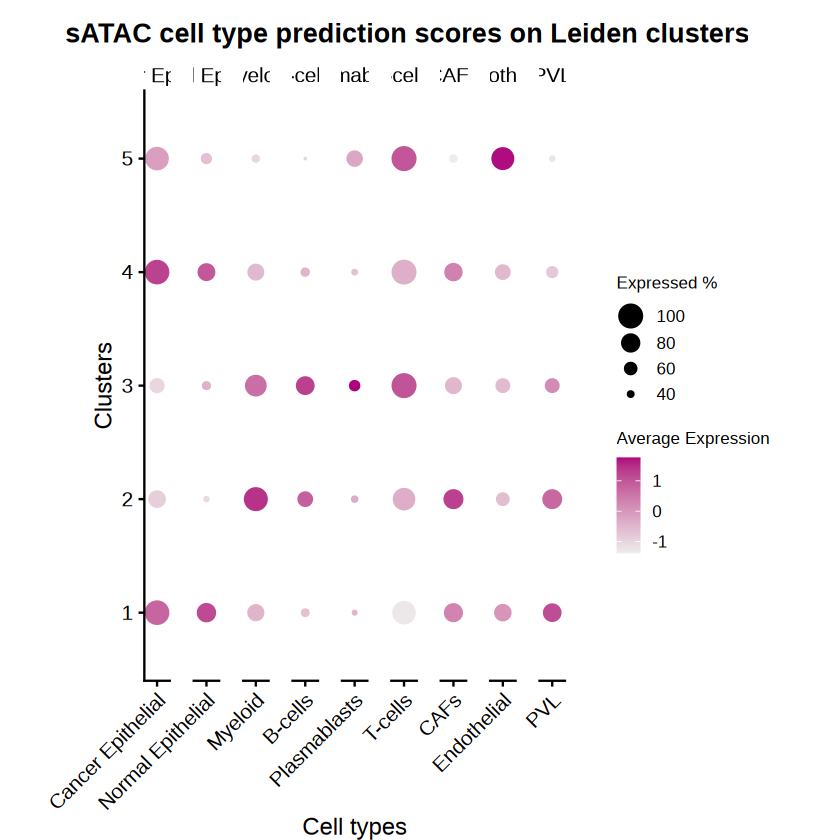

In [88]:
png_plot_file_name <- paste0(PATH_TO_FIGURES_SATAC, "dotplot_predictions_leiden_satac_denoised.png")
pdf_plot_file_name <- paste0(PATH_TO_FIGURES_SATAC, "dotplot_predictions_leiden_satac_denoised.pdf")

pdf(file = pdf_plot_file_name, width = 7, height = 3.8)

# Now plot
p <- DotPlot(signac_selected, features = prediction_features, cols = c("gray93", "#AE017E")) +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    axis.title.x.top = element_blank(),
    axis.text.x.top = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.line.x.top = element_blank(),
    # axis.text.x = element_text(angle = 45),
    plot.title = element_text(hjust = 0.3, vjust = 1),
    plot.margin = margin(0.5, 1, 0, 2, "cm"),  # bottom margin extended
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 10),
    legend.box.margin = margin(1.2, 0, 0, 1.2, "cm")
  ) +
  ggtitle("sATAC cell type prediction scores on Leiden clusters") + 
  scale_y_discrete(name = "Clusters") +
  scale_x_discrete(name = "Cell types", breaks = prediction_features, labels = desired_order) +
  RotatedAxis() +
  guides(color = guide_colorbar(barwidth = 1, barheight = 4, title = "Average Expression"), 
          size = guide_legend(reverse = TRUE, title = "Expressed %") ) # Adjust the size of the color bar

print(p)
dev.off()
ggsave(filename = png_plot_file_name, width = 7, height = 3.8, units = "in", dpi = 300)
print(p)

pdf 
  2

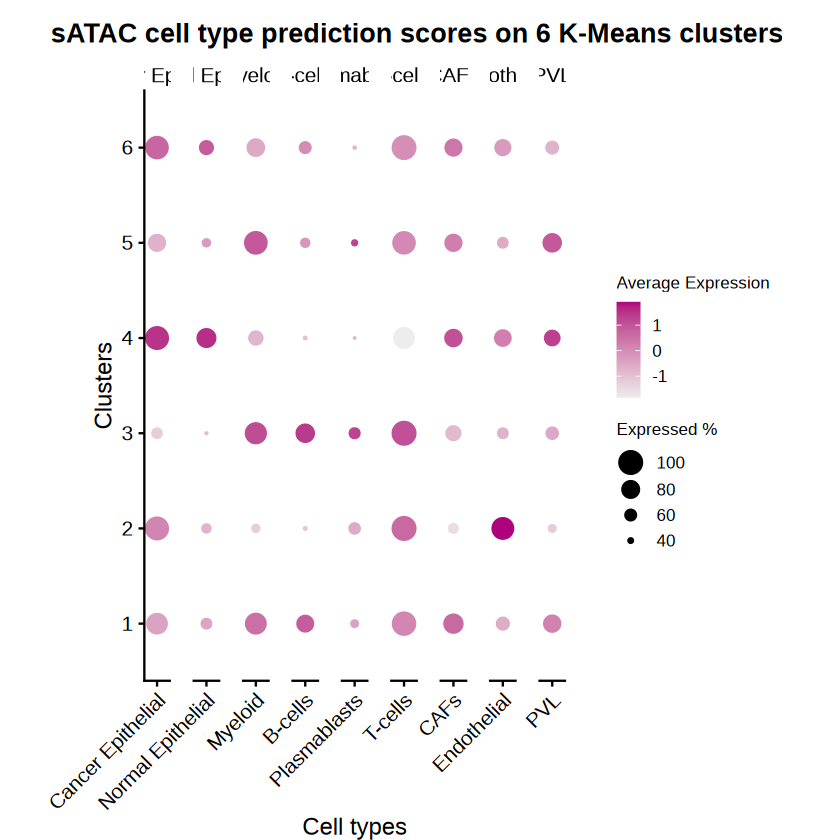

In [89]:
# # Now plot
# DotPlot(signac_selected, features = prediction_features, group.by = "kmeans_6_rna_act_dca", cols = c("gray93", "#AE017E")) +
#   scale_x_discrete(name = "Cell types", breaks = prediction_features, labels = desired_order) +
#   scale_y_discrete(name = "Clusters") +
#   theme(
#     plot.background = element_rect(fill = "white", color = NA),
#     axis.text.x = element_text(angle = 45, hjust = 1),
#     plot.title = element_text(hjust = 0.5),
#     plot.margin = margin(0, 1, 0, 2, "cm")  # bottom margin extended
#   ) +
#   ggtitle("sATAC cell type prediction scores on 6 K-Means clusters")
# ggsave("dotplot_predictions_6kmeans_clusters_satac_selected.png", width = 8, height = 5, units = "in", dpi = 300)


png_plot_file_name <- paste0(PATH_TO_FIGURES_SATAC, "dotplot_predictions_6kmeans_satac_denoised.png")
pdf_plot_file_name <- paste0(PATH_TO_FIGURES_SATAC, "dotplot_predictions_6kmeans_satac_denoised.pdf")

pdf(file = pdf_plot_file_name, width = 7, height = 3.8)

# Now plot
p <- DotPlot(signac_selected, features = prediction_features, group.by = "kmeans_6_rna_act_dca", cols = c("gray93", "#AE017E")) +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    axis.title.x.top = element_blank(),
    axis.text.x.top = element_blank(),
    axis.ticks.x.top = element_blank(),
    axis.line.x.top = element_blank(),
    # axis.text.x = element_text(angle = 45),
    plot.title = element_text(hjust = 0.3, vjust = 1),
    plot.margin = margin(0.5, 1, 0, 2, "cm"),  # bottom margin extended
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 10),
    legend.box.margin = margin(1.2, 0, 0, 1.2, "cm")
  ) +
  ggtitle("sATAC cell type prediction scores on 6 K-Means clusters") + 
  scale_y_discrete(name = "Clusters") +
  scale_x_discrete(name = "Cell types", breaks = prediction_features, labels = desired_order) +
  RotatedAxis() +
  guides(color = guide_colorbar(barwidth = 1, barheight = 4, title = "Average Expression"), 
          size = guide_legend(reverse = TRUE, title = "Expressed %") ) # Adjust the size of the color bar

print(p)
dev.off()
ggsave(filename = png_plot_file_name, width = 7, height = 3.8, units = "in", dpi = 300)
print(p)



In [90]:
# # save object with the single cell predictions
# saveRDS(satac_selected, "visium_brca_scpredicted.rds")
# saveRDS(combined, "atac_brca_scpredicted.rds")

----
# 7. - Comparison with image clustering

In [91]:
head(image_cluster_data$satac_100um_leiden_macenko)

NULL

In [127]:
plot_satac_dotplot_from_cluster_table <- function(cluster_df, 
                                            seurat_obj, 
                                            cluster_label = "image_cluster",
                                            desired_order = NULL,
                                            title = "sATAC cell type prediction scores - ",
                                            saving_folder_path,
                                            name) {
  # Filter rows with image clusters assigned
  cluster_df_filtered <- cluster_df %>%
    filter(!is.na(Cluster)) %>%
    mutate(barcode = as.character(barcode),
           cluster_label = as.factor(Cluster)) # uses Cluster from the image clustering

  # Only keep matching barcodes
  cluster_df_filtered$barcode <- paste0(cluster_df_filtered$barcode, "-1") # adapting to the sATAC barcode names system
  barcodes_to_keep <- intersect(cluster_df_filtered$barcode, colnames(seurat_obj))
  subset_obj <- subset(seurat_obj, cells = barcodes_to_keep)

  # Add image cluster to metadata
  subset_obj[[cluster_label]] <- cluster_df_filtered[match(Cells(subset_obj), cluster_df_filtered$barcode), "cluster_label"]

  # Handle cell type prediction features
  if (is.null(desired_order)) {
    # fallback
    prediction_scores <- grep("^prediction.score\\.", colnames(subset_obj@meta.data), value = TRUE)
    clean_names <- gsub("prediction.score.", "", prediction_scores, fixed = TRUE)
    names(prediction_scores) <- clean_names
  } else {
    clean_names <- make.names(desired_order)
    prediction_scores <- paste0("prediction.score.", clean_names)
    names(prediction_scores) <- desired_order
  }

  # build the dotplot
  png_plot_file_name <- paste0(saving_folder_path, "dotplot_predictions_image_clusters_", name, ".png")
  pdf_plot_file_name <- paste0(saving_folder_path, "dotplot_predictions_image_clusters_", name, ".pdf")

  # pdf(file = pdf_plot_file_name, width = 7, height = 3.8)
  # pdf(file = pdf_plot_file_name, width = 40, height = 23, unit = "cm")

  p <- DotPlot(subset_obj, features = prediction_scores, group.by = cluster_label, cols = c("gray93", "#AE017E")) +
    theme(
      plot.background = element_rect(fill = "white", color = NA),
      axis.title.x.top = element_blank(),
      axis.text.x.top = element_blank(),
      axis.ticks.x.top = element_blank(),
      axis.line.x.top = element_blank(),
      axis.text.x = element_text(size = 11),
      # axis.text.x = element_text(angle = 45),
      plot.title = element_text(hjust = 0.3, vjust = 1, size = 12),
      plot.margin = margin(0.5, 1, 0, 1, "cm"),  # bottom margin extended
      legend.title = element_text(size = 10),
      legend.text = element_text(size = 10),
      legend.box.margin = margin(2, 0, 0, 2, "cm")
      ) +
    ggtitle(paste(title, name)) + 
    scale_y_discrete(name = "Image Clusters") +
    scale_x_discrete(name = "Cell types", breaks = prediction_scores, labels = names(prediction_scores)) +
    RotatedAxis() +
    guides(color = guide_colorbar(barwidth = 1, barheight = 4, title = "Average Expression"), 
            size = guide_legend(reverse = TRUE, title = "Expressed %") ) # Adjust the size of the color bar
  
  # print(p)
  
  # dev.off()
  # ggsave(filename = png_plot_file_name, width = 7, height = 3.8, units = "cm", dpi = 300)
  ggsave(filename = png_plot_file_name, width = 18, height = 9, units = "cm", dpi = 300)
  ggsave(filename = pdf_plot_file_name, width = 18, height = 9, units = "cm", dpi = 300)

  return(p)
}

Warning message:
"Scaling data with a low number of groups may produce misleading results"


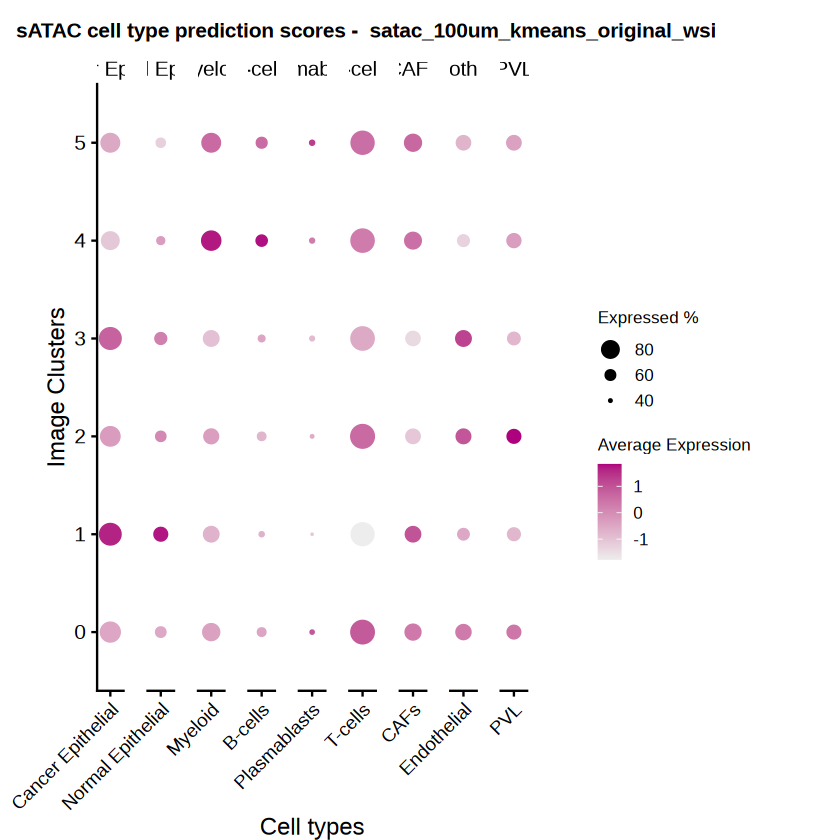

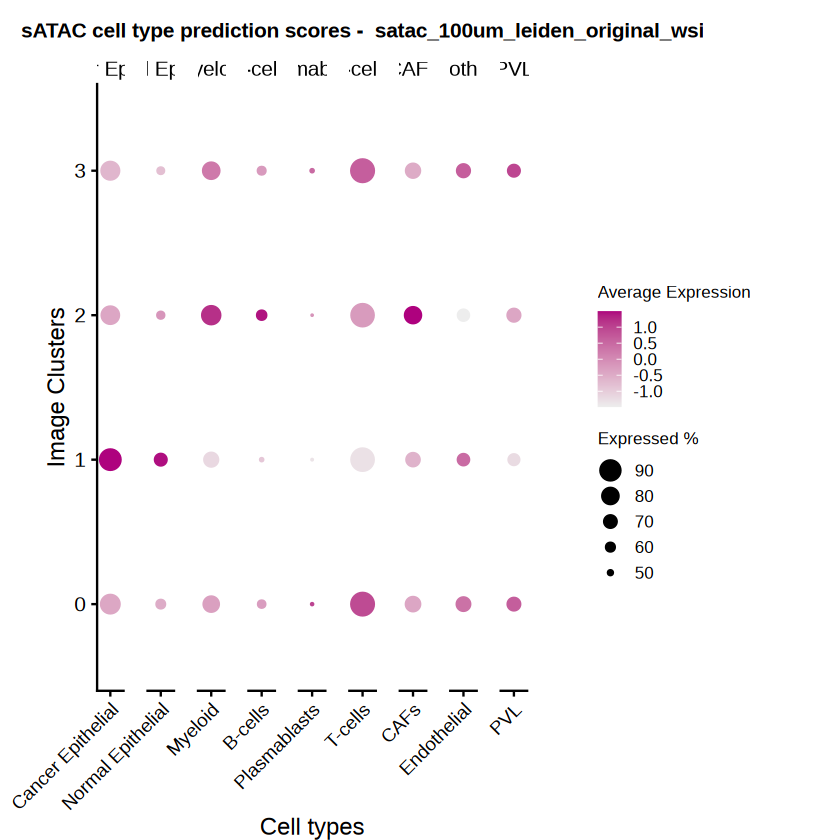

Warning message:
"Scaling data with a low number of groups may produce misleading results"


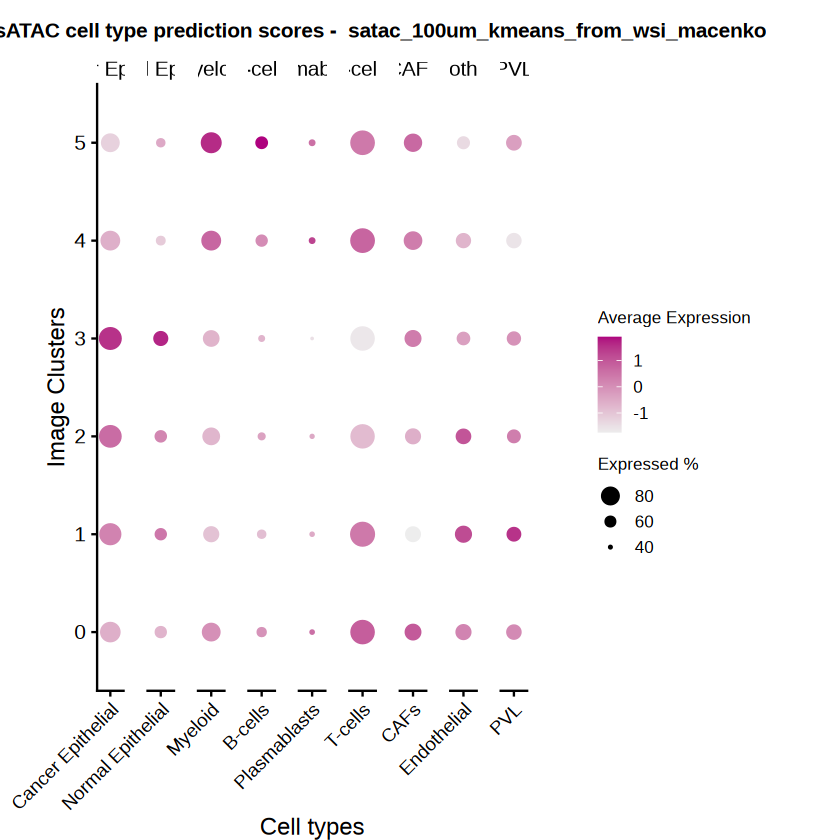

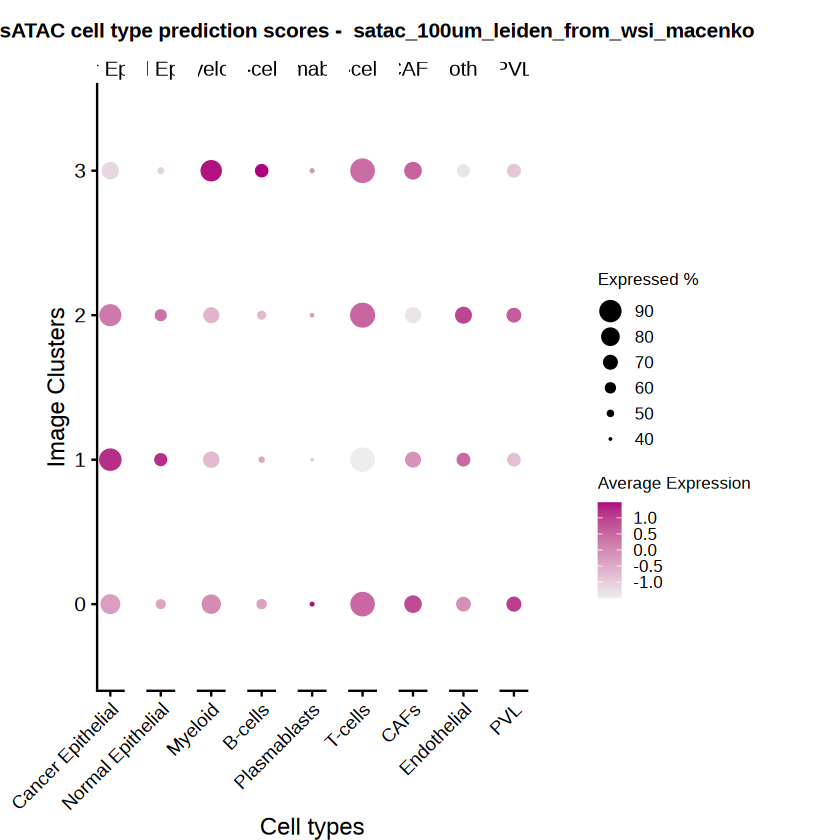

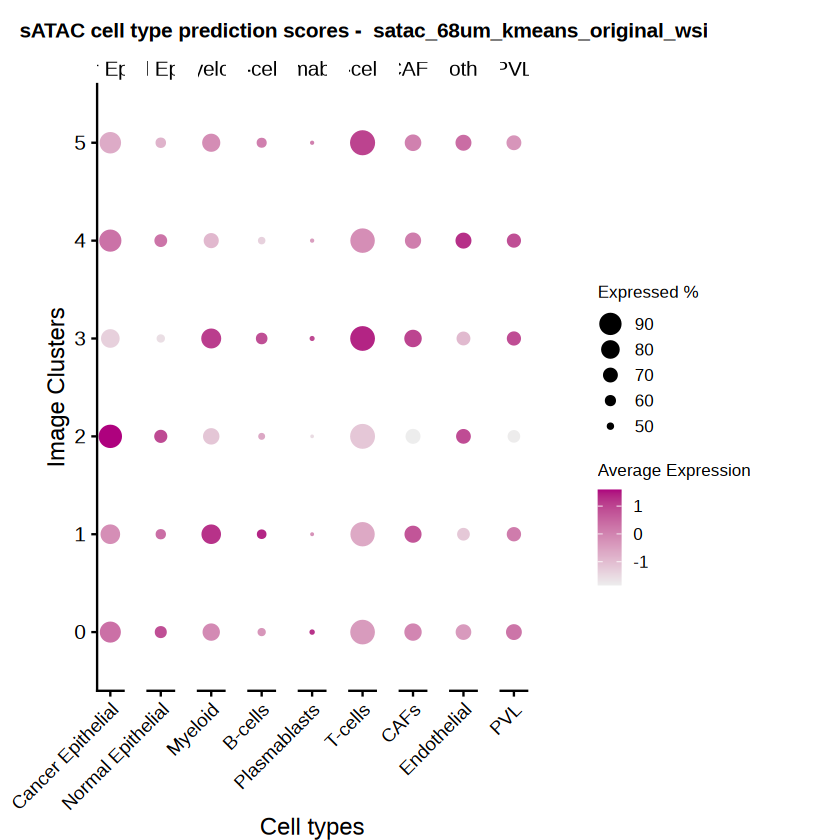

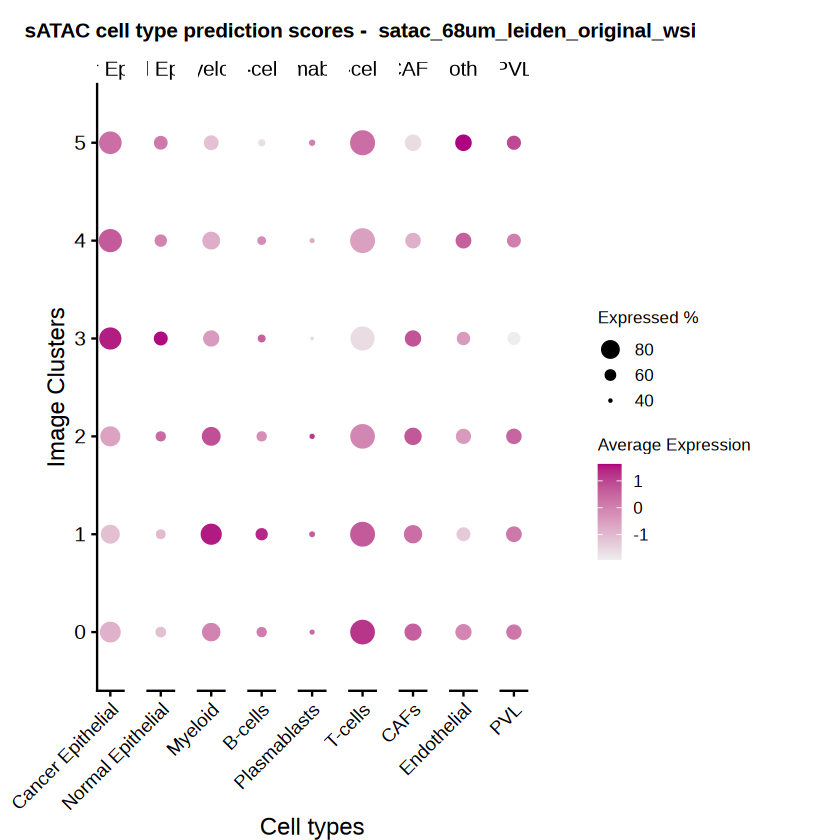

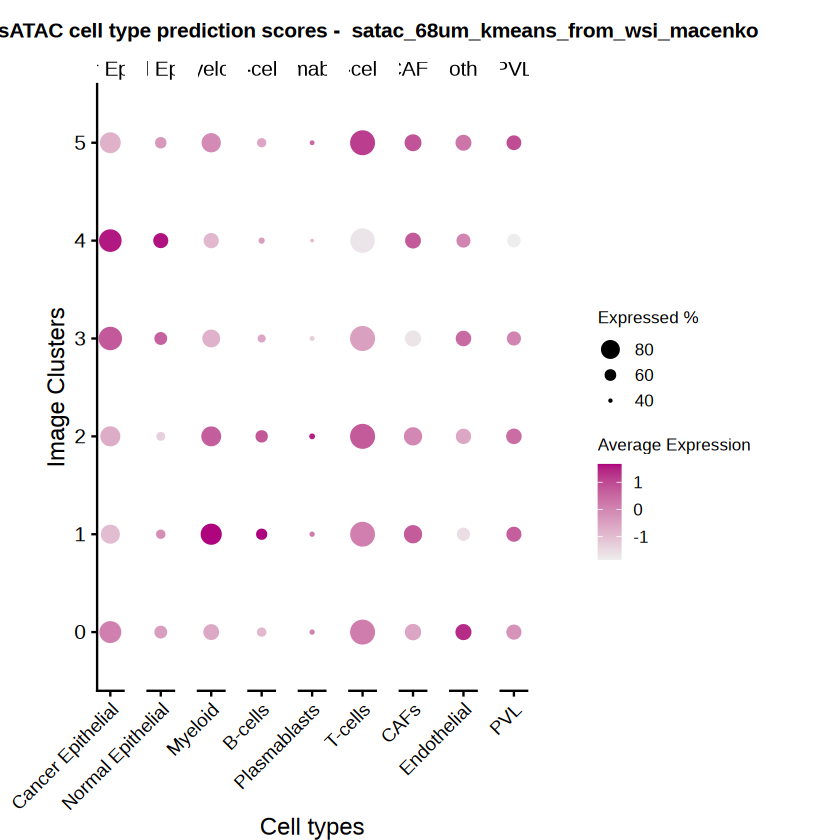

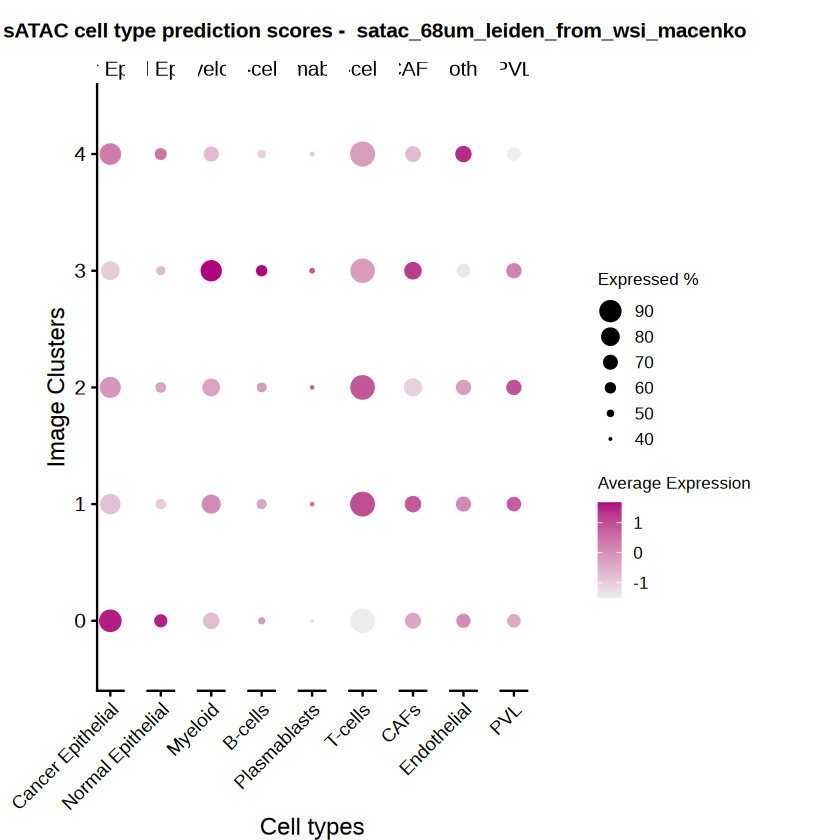

In [128]:
# Loop through each and generate plots
for (name in names(image_cluster_data)) {
  df <- image_cluster_data[[name]]

  # Plot
  p <- plot_satac_dotplot_from_cluster_table(
    cluster_df = df,
    seurat_obj = signac_selected,  # adapt this if using a different object
    cluster_label = paste0(name, "_image_cluster"),
    desired_order = desired_order,
    title = "sATAC cell type prediction scores - ", 
    saving_folder_path = PATH_TO_FIGURES_SATAC,
    name = name
  )

  print(p)
}